## 15. Participation Coefficient

Parcel-level participation coefficient: early vs. late session comparison.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------
DATA_ROOT = "../../../Data/"
PATH_ALL = os.path.join(DATA_ROOT, "all_subjects_yeo7_metrics.csv")

FIGURES_DIR = "../../../Results/Tessnim/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

# -------------------------------------------------------------------
# Load combined metrics and rebuild all_data
# -------------------------------------------------------------------
df_all = pd.read_csv(PATH_ALL)

expected_cols = {
    "subject", "session", "run", "condition",
    "parcel", "yeo_label", "pc_parcel", "wmd_parcel",
    "network", "segregation", "integration", "normalized_segregation",
    "pc_parcel_neg"
}
missing = expected_cols - set(df_all.columns)
if missing:
    raise ValueError(f"Missing columns in all_subjects_yeo7_metrics.csv: {missing}")

all_data = {}

for (sid, sess_id, run_key), g in df_all.groupby(["subject", "session", "run"]):
    g = g.sort_values("parcel")

    subj = all_data.setdefault(sid, {"sessions": {}})
    subj["yeo_labels"] = g["yeo_label"].to_numpy()


    sess_runs = subj["sessions"].setdefault(sess_id, {})

    # parcel-level metrics
    pc_parcel = g["pc_parcel"].to_numpy()
    wmd_parcel = g["wmd_parcel"].to_numpy()

    # network-level metrics: one row per network
    g_net = (
        g.drop_duplicates(["network"])
         .sort_values("network")
    )
    seg = g_net["segregation"].to_numpy()
    integ = g_net["integration"].to_numpy()
    normseg = g_net["normalized_segregation"].to_numpy()

    sess_runs[run_key] = {
        "condition": g["condition"].iloc[0],
        "pc_parcel": pc_parcel,
        "wmd_parcel": wmd_parcel,
        "segregation": seg,
        "integration": integ,
        "normalized_segregation": normseg,
        "pc_parcel_neg": g["pc_parcel_neg"].to_numpy() if "pc_parcel_neg" in g.columns else None,
    }

print(f"Reconstructed all_data for {len(all_data)} subjects from all_subjects_yeo7_metrics.csv.")

Reconstructed all_data for 21 subjects from all_subjects_yeo7_metrics.csv.


In [2]:
YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]

# ── PC data assembly ──────────────────────────────────────────────────────────
# Get yeo_cx (cortical labels after subcortical stripping) from any subject
_any_subj   = next(iter(all_data.values()))
_yeo        = _any_subj["yeo_labels"]
cortical_mask = (_yeo >= 1) & (_yeo <= 7)
yeo_cx      = _yeo[cortical_mask].astype(int)   # (n_cortical,) e.g. 200 values
N_PARC      = yeo_cx.shape[0]

SESSIONS    = [f"V{i:02d}" for i in range(1, 16)]   # V01 … V15
YEO_COLORS  = ["#8B0000","#4682B4","#2E8B57","#9370DB","#F0E68C","#FF8C00","#DC143C"]
# matches: Visual, Somotor, DorsAttn, VentAttn, Limbic, FrontPar, Default

# ── Build (n_subjects × n_sessions × n_parcels) tensor ───────────────────────
# For Feedback runs only (average across runs within session)
def pc_session_matrix(all_data, condition="Feedback"):
    """
    Returns
    -------
    mat : (n_subjects, n_sessions, n_parcels)  NaN where missing
    sids: list of subject IDs in row order
    """
    sids = sorted(all_data.keys())
    mat  = np.full((len(sids), len(SESSIONS), N_PARC), np.nan)
    for si, sid in enumerate(sids):
        for vi, sess in enumerate(SESSIONS):
            runs = all_data[sid]["sessions"].get(sess, {})
            vals = [rd["pc_parcel"] for rd in runs.values()
                    if rd["condition"] == condition and "pc_parcel" in rd]
            if vals:
                mat[si, vi] = np.nanmean(vals, axis=0)
    return mat, sids

pc_fb,  sids = pc_session_matrix(all_data, condition="Feedback")
pc_nfb, _    = pc_session_matrix(all_data, condition="NoFeedback")
pc_tr, _ = pc_session_matrix(all_data, condition="Transfer")
# group mean over subjects: (n_sessions, n_parcels)
pc_fb_mean   = np.nanmean(pc_fb,  axis=0)
pc_nfb_mean  = np.nanmean(pc_nfb, axis=0)


C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\2275572570.py:48: RuntimeWarning: Mean of empty slice
  pc_nfb_mean  = np.nanmean(pc_nfb, axis=0)


In [3]:
# Compute boundaries and centers on the SORTED parcel order (by network),
# which is what the bar plot uses — this gives exactly 7 entries for 7 networks.
sort_idx_net = np.argsort(yeo_cx, kind="stable")
yeo_sorted   = yeo_cx[sort_idx_net]

boundaries  = []
net_centers = []
for net_id in range(1, 8):
    idx = np.where(yeo_sorted == net_id)[0]
    if idx.size == 0:
        continue
    boundaries.append(idx[0])
    net_centers.append(0.5 * (idx[0] + idx[-1]))

In [4]:
import pandas as pd
from collections import defaultdict

def count_conditions_per_session(all_data):
    """
    Count Feedback / Transfer / NoFeedback runs per session across all subjects.

    Returns
    -------
    pd.DataFrame  — rows = sessions, columns = Feedback, Transfer, NoFeedback, Total
                    values = number of (subject × run) samples
    """
    CONDITIONS = ["Feedback", "Transfer", "NoFeedback"]

    # counts[session][condition] = number of runs across all subjects
    counts = defaultdict(lambda: defaultdict(int))

    for sid, subj in all_data.items():
        for sess_id, sess_runs in subj["sessions"].items():
            for run_key, rd in sess_runs.items():
                cond = rd["condition"]
                counts[sess_id][cond] += 1

    sessions_sorted = sorted(counts.keys(),
                             key=lambda s: int(s.replace("V", "")))

    rows = []
    for sess in sessions_sorted:
        row = {"Session": sess}
        total = 0
        for cond in CONDITIONS:
            n = counts[sess][cond]
            row[cond] = n
            total += n
        row["Total"] = total
        rows.append(row)

    df = pd.DataFrame(rows).set_index("Session")

    # summary row
    df.loc["TOTAL"] = df.sum()

    return df


df_counts = count_conditions_per_session(all_data)
df_counts

,Feedback,Transfer,NoFeedback,Total
Session,,,,
V01,134,0,0,134
V02,133,0,0,133
V03,133,0,0,133
V04,129,2,0,131
V05,90,42,0,132
V06,127,5,0,132
V07,83,48,0,131
V08,94,40,0,134
V09,129,2,0,131


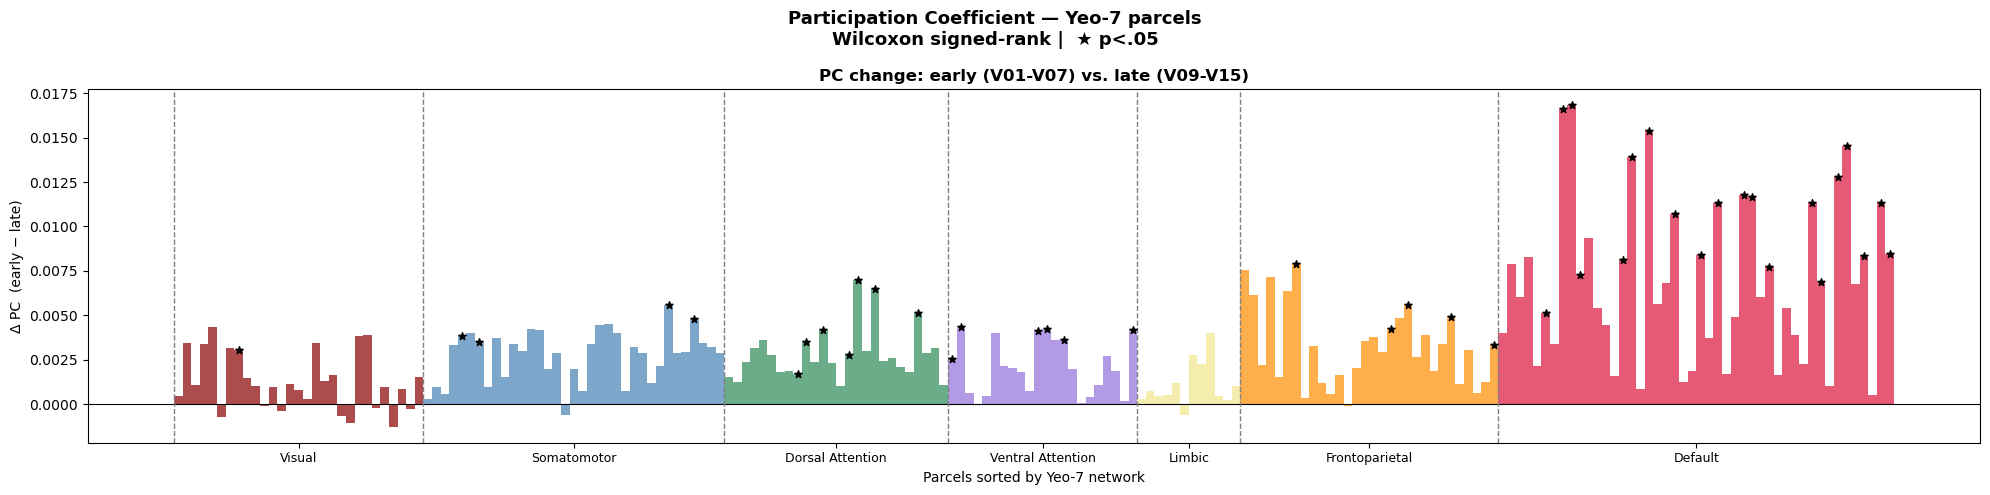

In [5]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# Pool all conditions into one matrix
pc_all = np.nanmean(np.stack([pc_fb, pc_nfb, pc_tr], axis=0), axis=0)  # (n_subj, n_sess, n_parc)

EARLY = [SESSIONS.index(s) for s in ["V01", "V02", "V03", "V04", "V05", "V06", "V07"]]
LATE  = [SESSIONS.index(s) for s in ["V09", "V10" ,"V11","V12", "V13", "V14", "V15"]]

# Per subject, average PC over early and late sessions
pc_early_subj = np.nanmean(pc_all[:, EARLY, :], axis=1)   # (n_subj, n_parcels)
pc_late_subj  = np.nanmean(pc_all[:, LATE,  :], axis=1)

# Effect size (mean difference) and Wilcoxon p-value per parcel
diff   =  pc_early_subj - pc_late_subj                  # (n_subj, n_parcels)
effect = np.nanmean(diff, axis=0)                         # (n_parcels,)

pvals = np.array([
    wilcoxon(
        diff[~np.isnan(diff[:, p]), p],
        alternative="two-sided"
    ).pvalue
    if (np.sum(~np.isnan(diff[:, p])) >= 2
        and not np.all(diff[~np.isnan(diff[:, p]), p] == 0))
    else np.nan
    for p in range(N_PARC)
])

# FDR correction (BH) applied only to valid p-values
valid      = ~np.isnan(pvals)
_, pvals_fdr, _, _ = multipletests(pvals[valid], method="fdr_bh")
pvals_corr = np.full(N_PARC, np.nan)
pvals_corr[valid] = pvals_fdr

sig = pvals_corr < 0.05

# ── Plot: effect size bar, significant parcels marked ────────────────────────
sort_idx_net  = np.argsort(yeo_cx, kind="stable")
effect_sorted = effect[sort_idx_net]
sig_sorted    = sig[sort_idx_net]
yeo_s         = yeo_cx[sort_idx_net]
colors_s      = [YEO_COLORS[y - 1] for y in yeo_s]

fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(range(N_PARC), effect_sorted, color=colors_s, width=1.0, linewidth=0, alpha=0.7)

sig_x = np.where(sig_sorted)[0]
sig_y = effect_sorted[sig_sorted]
ax.scatter(sig_x, sig_y, marker="*", color="black", s=30, zorder=5)

ax.axhline(0, color="black", linewidth=0.8)
for b in boundaries:
    ax.axvline(b - 0.5, color="gray", linewidth=1, linestyle="--")

ax.set_xticks(net_centers)
ax.set_xticklabels(YEO_NAMES, fontsize=9)
ax.set_ylabel("\u0394 PC  (early \u2212 late)")
ax.set_title("PC change: early (V01-V07) vs. late (V09-V15)", fontweight="bold")
ax.set_xlabel("Parcels sorted by Yeo-7 network")

from matplotlib.patches import Patch
legend_els = [Patch(color=YEO_COLORS[i], label=YEO_NAMES[i]) for i in range(7)]
fig.suptitle(
    "Participation Coefficient — Yeo-7 parcels\n"
    "Wilcoxon signed-rank |  ★ p<.05",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pc_yeo7_parcel_wilcoxon_time.png"), dpi=300, bbox_inches="tight")
plt.show()


In [6]:
from collections import Counter

sig_networks = [YEO_NAMES[yeo_cx[p] - 1] for p in range(N_PARC) if sig[p]]
counts = Counter(sig_networks)

print(f"\nEpoch (Early vs Late) — significant parcels: {sig.sum()} / {N_PARC}")
for net, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {net}: {n}")



Epoch (Early vs Late) — significant parcels: 43 / 200
  Default: 20
  Dorsal Attention: 7
  Ventral Attention: 6
  Frontoparietal: 5
  Somatomotor: 4
  Visual: 1


In [7]:
print("Raw p-values (min, median, % < 0.05):")
print(f"  min    = {np.nanmin(pvals):.4f}")
print(f"  median = {np.nanmedian(pvals):.4f}")
print(f"  % < 0.05 (uncorrected) = {np.nanmean(pvals < 0.05)*100:.1f}%")
print(f"  % < 0.05 (FDR)         = {np.nanmean(pvals_corr < 0.05)*100:.1f}%")

Raw p-values (min, median, % < 0.05):
  min    = 0.0000
  median = 0.1111
  % < 0.05 (uncorrected) = 39.5%
  % < 0.05 (FDR)         = 21.5%


In [8]:
n_valid = np.array([np.sum(~np.isnan(diff[:, p])) for p in range(N_PARC)])
print(f"Subjects with valid early+late data: min={n_valid.min()}, mean={n_valid.mean():.1f}")

Subjects with valid early+late data: min=21, mean=21.0


C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\3948056469.py:7: RuntimeWarning: Mean of empty slice
  pc_ctrl = np.nanmean(np.stack([pc_nofb, pc_tr], axis=0), axis=0)  # (n_subj, n_sess, n_parc)


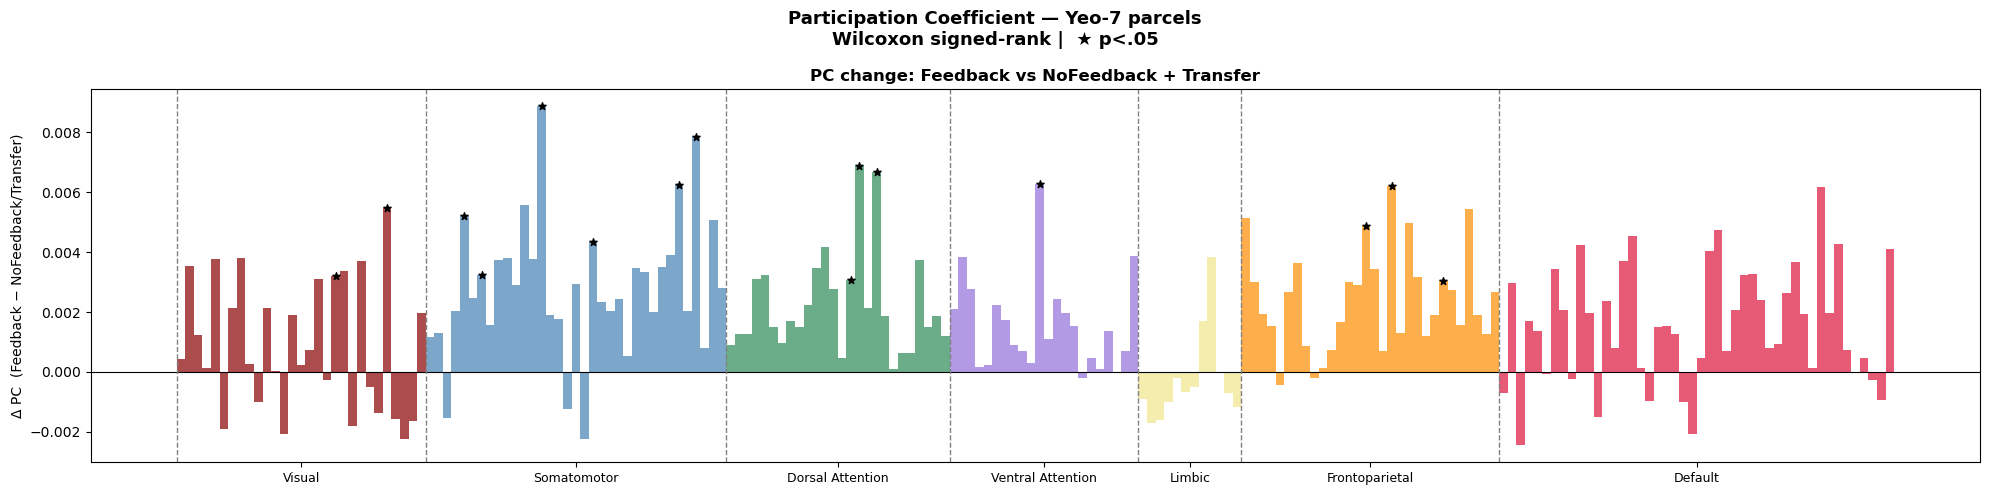

In [9]:
# ── NEW: Feedback vs (NoFeedback + Transfer), per parcel ─────────────────────
pc_nofb, _ = pc_session_matrix(all_data, condition="NoFeedback")
pc_tr,   _ = pc_session_matrix(all_data, condition="Transfer")

# Pool NoFeedback and Transfer: average across whichever runs exist per subject
# NaN-safe: if a subject has only one of the two, that one is used
pc_ctrl = np.nanmean(np.stack([pc_nofb, pc_tr], axis=0), axis=0)  # (n_subj, n_sess, n_parc)

# Per-subject mean across all sessions
mu_fb   = np.nanmean(pc_fb,   axis=1)   # (n_subj, n_parc)
mu_ctrl = np.nanmean(pc_ctrl, axis=1)

diff   = mu_fb - mu_ctrl
effect = np.nanmean(diff, axis=0)       # keep mean difference, consistent with Cell 5

pvals = np.array([
    wilcoxon(
        diff[~np.isnan(diff[:, p]), p],
        alternative="two-sided"
    ).pvalue
    if (np.sum(~np.isnan(diff[:, p])) >= 5
        and not np.all(diff[~np.isnan(diff[:, p]), p] == 0))
    else np.nan
    for p in range(N_PARC)
])

valid = ~np.isnan(pvals)
_, pvals_fdr, _, _ = multipletests(pvals[valid], method="fdr_bh")
pvals_corr = np.full(N_PARC, np.nan)
pvals_corr[valid] = pvals_fdr
sig = pvals_corr < 0.05

# Plot — identical style to Cell 5
effect_sorted = effect[sort_idx_net]
sig_sorted    = sig[sort_idx_net]
colors_s      = [YEO_COLORS[y - 1] for y in yeo_cx[sort_idx_net]]

fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(range(N_PARC), effect_sorted, color=colors_s, width=1.0, linewidth=0, alpha=0.7)
sig_x = np.where(sig_sorted)[0]
ax.scatter(sig_x, effect_sorted[sig_sorted], marker="*", color="black", s=30, zorder=5)
ax.axhline(0, color="black", linewidth=0.8)
for b in boundaries:
    ax.axvline(b - 0.5, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(net_centers)
ax.set_xticklabels(YEO_NAMES, fontsize=9)
ax.set_ylabel("Δ PC  (Feedback − NoFeedback/Transfer)")

ax.set_title("PC change: Feedback vs NoFeedback + Transfer", fontweight="bold")



fig.suptitle(
    "Participation Coefficient — Yeo-7 parcels\n"
    "Wilcoxon signed-rank |  ★ p<.05",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pc_yeo7_parcel_wilcoxon_condition.png"), dpi=300, bbox_inches="tight")
plt.show()

In [10]:
sig_networks = [YEO_NAMES[yeo_cx[p] - 1] for p in range(N_PARC) if sig[p]]
from collections import Counter
counts = Counter(sig_networks)

print(f"\nSignificant parcels (FDR p<.05): {sig.sum()} / {N_PARC}")
for net, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {net}: {n}")



Significant parcels (FDR p<.05): 15 / 200
  Somatomotor: 6
  Dorsal Attention: 3
  Frontoparietal: 3
  Visual: 2
  Ventral Attention: 1


Yeo-17 cortical parcels: 200
Sub-networks present: ['ContA' 'ContB' 'ContC' 'DefaultA' 'DefaultB' 'DefaultC' 'DorsAttnA'
 'DorsAttnB' 'LimbicA' 'LimbicB' 'SalVentAttnA' 'SalVentAttnB' 'SomMotA'
 'SomMotB' 'TempPar' 'VisCent' 'VisPeri']


C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\4150116342.py:85: RuntimeWarning: Mean of empty slice
  pc17_ctrl = np.nanmean(np.stack([pc17_nfb, pc17_tr], axis=0), axis=0)


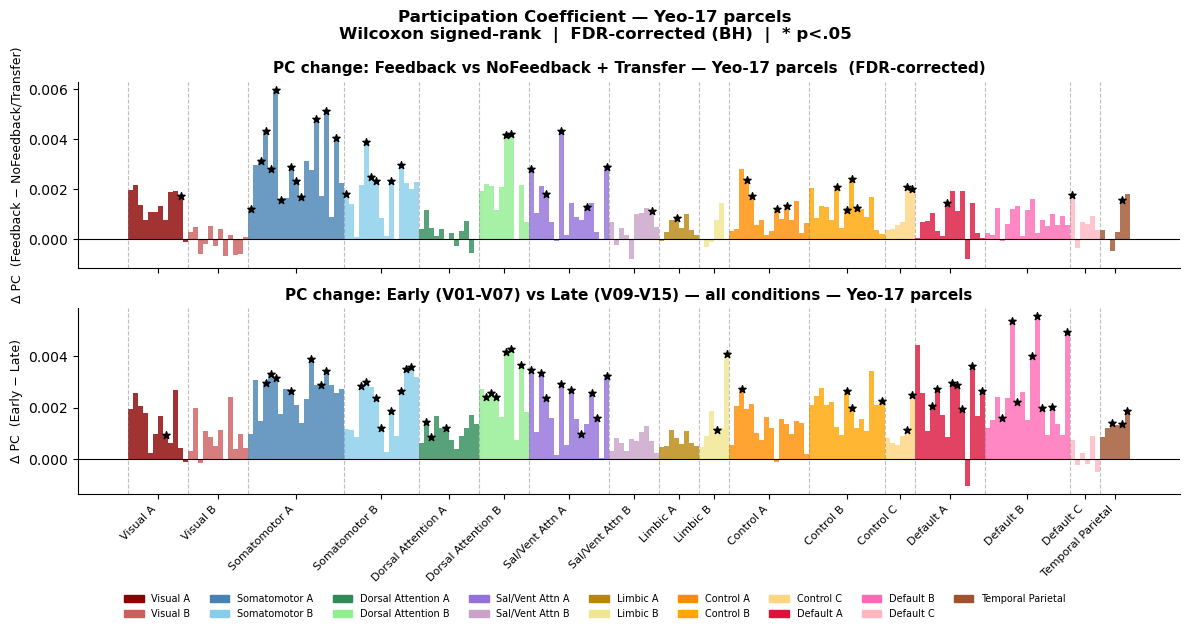

In [11]:
# ── Yeo-17 parcel-level PC analysis ───────────────────────────────────────────
PATH_17 = os.path.join(DATA_ROOT, "all_subjects_yeo17_metrics.csv")

YEO17_ORDER = [
    "VisCent", "VisPeri", "SomMotA", "SomMotB",
    "DorsAttnA", "DorsAttnB", "SalVentAttnA", "SalVentAttnB",
    "LimbicA", "LimbicB", "ContA", "ContB", "ContC",
    "DefaultA", "DefaultB", "DefaultC", "TempPar",
]
YEO17_NAME_MAP = {
    "VisCent": "Visual A",             "VisPeri": "Visual B",
    "SomMotA": "Somatomotor A",        "SomMotB": "Somatomotor B",
    "DorsAttnA": "Dorsal Attention A", "DorsAttnB": "Dorsal Attention B",
    "SalVentAttnA": "Sal/Vent Attn A", "SalVentAttnB": "Sal/Vent Attn B",
    "LimbicA": "Limbic A",             "LimbicB": "Limbic B",
    "ContA": "Control A",              "ContB": "Control B",
    "ContC": "Control C",              "DefaultA": "Default A",
    "DefaultB": "Default B",           "DefaultC": "Default C",
    "TempPar": "Temporal Parietal",
}
# One colour per Yeo-17 sub-network (paired shades within each Yeo-7 parent)
YEO17_COLORS = {
    "VisCent": "#8B0000",     "VisPeri": "#CD5C5C",
    "SomMotA": "#4682B4",     "SomMotB": "#87CEEB",
    "DorsAttnA": "#2E8B57",   "DorsAttnB": "#90EE90",
    "SalVentAttnA": "#9370DB","SalVentAttnB": "#C8A2C8",
    "LimbicA": "#B8860B",     "LimbicB": "#F0E68C",
    "ContA": "#FF8C00",       "ContB": "#FFA500",     "ContC": "#FFD580",
    "DefaultA": "#DC143C",    "DefaultB": "#FF69B4",
    "DefaultC": "#FFB6C1",    "TempPar": "#A0522D",
}

# Load Yeo-17 CSV
df_17 = pd.read_csv(PATH_17)

# Build cortical mask and parcel-level arrays from Yeo-17 CSV
# Each parcel appears once per subject/session/run — get the stable mapping
parcel_net17 = (
    df_17[["parcel", "network"]]
    .drop_duplicates("parcel")
    .sort_values("parcel")
)
# Keep only parcels whose network is in YEO17_ORDER (drop subcortical)
cortical_mask17 = parcel_net17["network"].isin(YEO17_ORDER).values
net17_labels    = parcel_net17.loc[cortical_mask17, "network"].values  # (N_PARC17,)
N_PARC17        = len(net17_labels)

print(f"Yeo-17 cortical parcels: {N_PARC17}")
print(f"Sub-networks present: {np.unique(net17_labels)}")

# ── Rebuild all_data from Yeo-17 CSV ──────────────────────────────────────────
all_data17 = {}
for (sid, sess_id, run_key), g in df_17.groupby(["subject", "session", "run"]):
    g = g.sort_values("parcel")
    subj = all_data17.setdefault(sid, {"sessions": {}})
    subj["net17_labels"] = g["network"].values
    all_data17[sid]["sessions"].setdefault(sess_id, {})[run_key] = {
        "condition": g["condition"].iloc[0],
        "pc_parcel": g["pc_parcel"].values,
    }

sids17 = sorted(all_data17.keys())

# ── Build (subjects × sessions × parcels) matrix ──────────────────────────────
def pc_matrix17(condition):
    mat = np.full((len(sids17), len(SESSIONS), N_PARC17), np.nan)
    for si, sid in enumerate(sids17):
        for vi, sess in enumerate(SESSIONS):
            runs = all_data17[sid]["sessions"].get(sess, {})
            vals = [
                rd["pc_parcel"][cortical_mask17]
                for rd in runs.values()
                if rd["condition"] == condition
            ]
            if vals:
                mat[si, vi] = np.nanmean(vals, axis=0)
    return mat

pc17_fb  = pc_matrix17("Feedback")
pc17_tr  = pc_matrix17("Transfer")
pc17_nfb = pc_matrix17("NoFeedback")

# Pool all conditions for early vs late
pc17_all  = np.nanmean(np.stack([pc17_fb, pc17_tr, pc17_nfb], axis=0), axis=0)
pc17_ctrl = np.nanmean(np.stack([pc17_nfb, pc17_tr], axis=0), axis=0)

EARLY17 = [SESSIONS.index(s) for s in ["V01", "V02", "V03", "V04", "V05", "V06", "V07"]]
LATE17  = [SESSIONS.index(s) for s in ["V09", "V10", "V11", "V12", "V13", "V14", "V15"]]

# ── Per-subject means ──────────────────────────────────────────────────────────
mu17_fb    = np.nanmean(pc17_fb,   axis=1)
mu17_ctrl  = np.nanmean(pc17_ctrl, axis=1)
mu17_early = np.nanmean(pc17_all[:, EARLY17, :], axis=1)
mu17_late  = np.nanmean(pc17_all[:, LATE17,  :], axis=1)

# ── Wilcoxon per parcel ────────────────────────────────────────────────────────
def parcel_wilcoxon17(a, b):
    pvals  = np.full(N_PARC17, np.nan)
    effect = np.full(N_PARC17, np.nan)
    for p in range(N_PARC17):
        diff  = a[:, p] - b[:, p]
        valid = ~np.isnan(diff)
        d     = diff[valid]
        effect[p] = np.nanmean(diff)
        if len(d) < 5 or np.all(d == 0):
            continue
        try:
            _, pvals[p] = wilcoxon(d, alternative="two-sided")
        except ValueError:
            pass
    valid_mask = ~np.isnan(pvals)
    pvals_fdr  = np.full(N_PARC17, np.nan)
    if valid_mask.any():
        _, corrected, _, _ = multipletests(pvals[valid_mask], method="fdr_bh")
        pvals_fdr[valid_mask] = corrected
    return effect, pvals_fdr

eff_cond,  pfdr_cond  = parcel_wilcoxon17(mu17_fb,   mu17_ctrl)
eff_epoch, pfdr_epoch = parcel_wilcoxon17(mu17_early, mu17_late)

# ── Sort parcels by Yeo-17 network order ──────────────────────────────────────
sort_idx17 = np.argsort(
    [YEO17_ORDER.index(n) for n in net17_labels], kind="stable"
)
net17_sorted = net17_labels[sort_idx17]

# Network boundaries and centres for x-axis labels
boundaries17, net_centers17, net_labels17 = [], [], []
for net in YEO17_ORDER:
    idx = np.where(net17_sorted == net)[0]
    if idx.size == 0:
        continue
    boundaries17.append(idx[0])
    net_centers17.append(0.5 * (idx[0] + idx[-1]))
    net_labels17.append(YEO17_NAME_MAP[net])

colors17 = [YEO17_COLORS[n] for n in net17_sorted]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, effect, pvals_fdr, title, ylabel in [
    (axes[0],
     eff_cond[sort_idx17],  pfdr_cond[sort_idx17],
     "PC change: Feedback vs NoFeedback + Transfer — Yeo-17 parcels  (FDR-corrected)",
     "Δ PC  (Feedback − NoFeedback/Transfer)"),
    (axes[1],
     eff_epoch[sort_idx17], pfdr_epoch[sort_idx17],
     "PC change: Early (V01-V07) vs Late (V09-V15) — all conditions — Yeo-17 parcels",
     "Δ PC  (Early − Late)"),
]:
    x = np.arange(N_PARC17)
    ax.bar(x, effect, color=colors17, width=1.0, linewidth=0, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)

    # Sub-network boundary lines
    for b in boundaries17:
        ax.axvline(b - 0.5, color="gray", linewidth=0.8,
                   linestyle="--", alpha=0.5)

    # Stars — scatter marker at each significant parcel
    sig_x = np.where(pvals_fdr < 0.05)[0]
    ax.scatter(sig_x, effect[sig_x], marker="*", color="black", s=30, zorder=5)

    ax.set_xticks(net_centers17)
    ax.set_xticklabels(net_labels17, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_els = [
    Patch(color=YEO17_COLORS[net], label=YEO17_NAME_MAP[net])
    for net in YEO17_ORDER
]
fig.legend(handles=legend_els, loc="lower center",
           ncol=9, fontsize=7, frameon=False,
           bbox_to_anchor=(0.5, -0.05))

fig.suptitle(
    "Participation Coefficient — Yeo-17 parcels\n"
    "Wilcoxon signed-rank  |  FDR-corrected (BH)  |  * p<.05",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pc_yeo17_parcel_wilcoxon.png"), dpi=300, bbox_inches="tight")
plt.show()

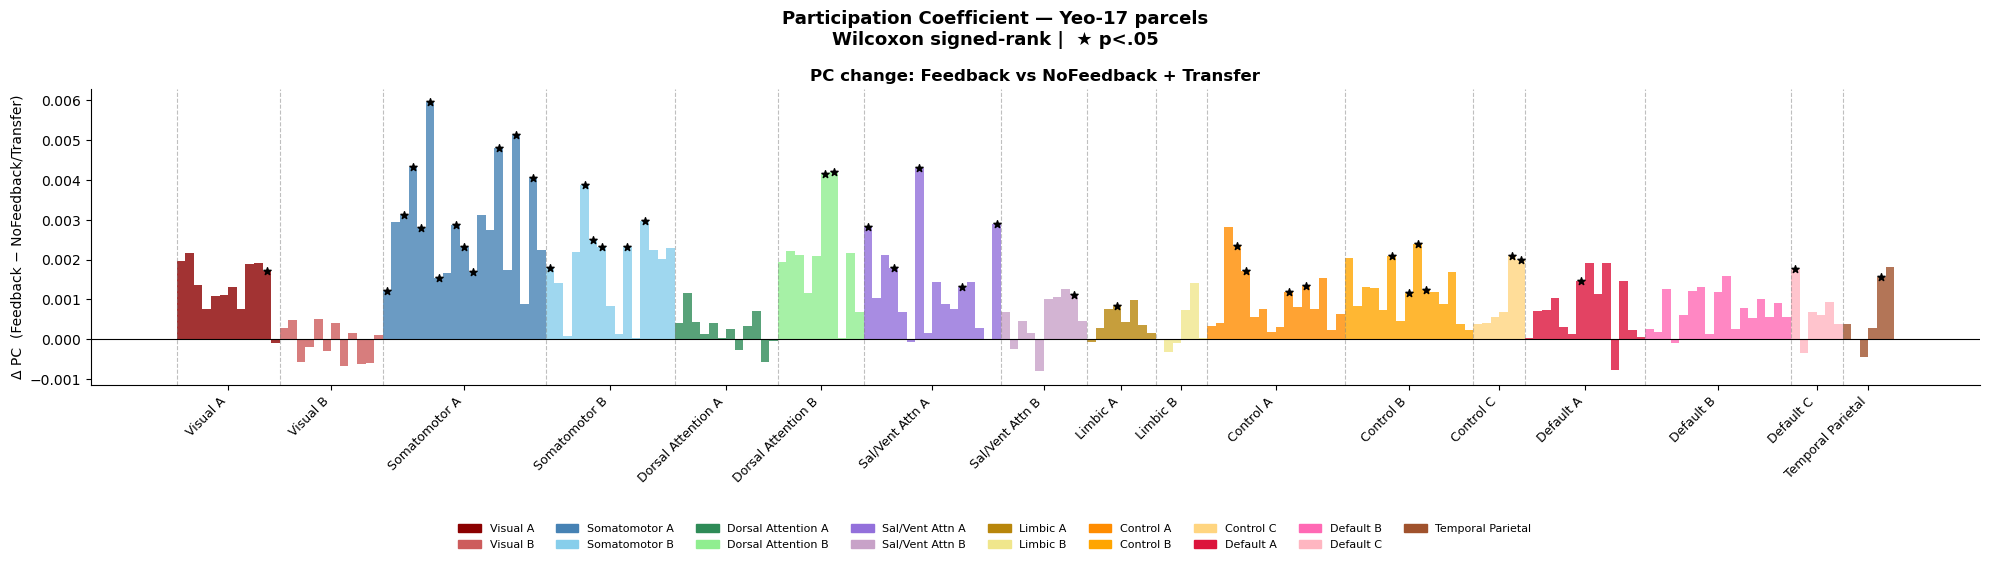

In [12]:
# ── Plot 1: Feedback vs NoFeedback + Transfer ──────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(20, 5))

effect    = eff_cond[sort_idx17]
pvals_fdr = pfdr_cond[sort_idx17]
sig       = pvals_fdr < 0.05

x = np.arange(N_PARC17)
ax1.bar(x, effect, color=colors17, width=1.0, linewidth=0, alpha=0.8)
ax1.axhline(0, color="black", linewidth=0.8)

for b in boundaries17:
    ax1.axvline(b - 0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

sig_x = np.where(sig)[0]
ax1.scatter(sig_x, effect[sig_x], marker="*", color="black", s=30, zorder=5)

ax1.set_xticks(net_centers17)
ax1.set_xticklabels(net_labels17, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("Δ PC  (Feedback − NoFeedback/Transfer)", fontsize=10)
ax1.set_title(
    "PC change: Feedback vs NoFeedback + Transfer",
    fontsize=12, fontweight="bold"
)
ax1.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch
legend_els = [
    Patch(color=YEO17_COLORS[net], label=YEO17_NAME_MAP[net])
    for net in YEO17_ORDER
]
fig1.legend(handles=legend_els, loc="lower center",
            ncol=9, fontsize=8, frameon=False,
            bbox_to_anchor=(0.5, -0.12))

fig1.suptitle(
    "Participation Coefficient — Yeo-17 parcels\n"
    "Wilcoxon signed-rank |  ★ p<.05",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pc_yeo17_parcel_wilcoxon_condition.png"), dpi=300, bbox_inches="tight")
plt.show()

In [13]:
from collections import Counter

for label, pfdr in [("Condition (Feedback vs ctrl)", pfdr_cond),
                    ("Epoch (Late vs Early)",        pfdr_epoch)]:
    sig17 = pfdr < 0.05
    counts17 = Counter(net17_labels[sig17])
    print(f"\n{label} — significant parcels: {sig17.sum()} / {N_PARC17}")
    for net, n in sorted(counts17.items(), key=lambda x: -x[1]):
        print(f"  {YEO17_NAME_MAP[net]}: {n}")




Condition (Feedback vs ctrl) — significant parcels: 41 / 200
  Somatomotor A: 12
  Somatomotor B: 6
  Sal/Vent Attn A: 5
  Control A: 4
  Control B: 4
  Dorsal Attention B: 2
  Control C: 2
  Limbic A: 1
  Default C: 1
  Default A: 1
  Visual A: 1
  Sal/Vent Attn B: 1
  Temporal Parietal: 1

Epoch (Late vs Early) — significant parcels: 60 / 200
  Sal/Vent Attn A: 9
  Somatomotor B: 8
  Default B: 8
  Somatomotor A: 7
  Default A: 7
  Dorsal Attention B: 6
  Dorsal Attention A: 3
  Temporal Parietal: 3
  Control B: 3
  Limbic B: 2
  Control C: 2
  Control A: 1
  Visual A: 1


In [14]:
UTILS_DIR = "../Utils/"

matched = pd.read_csv(os.path.join(UTILS_DIR, "matched_labels_exact.csv"))
label17_map = dict(zip(matched["ROI Label"], matched["label_df2"]))
cortical_parcel_nums = parcel_net17.loc[cortical_mask17, "parcel"].values

for label, pfdr in [("Condition (pos PC)", pfdr_cond),
                    ("Epoch (pos PC)",     pfdr_epoch)]:
    sig17 = pfdr < 0.05
    somemot_sig = sig17 & np.isin(net17_labels, ["SomMotA", "SomMotB"])
    print(f"\n{label} — SomMot significant: {somemot_sig.sum()}")
    for p in np.where(somemot_sig)[0]:
        roi = label17_map.get(cortical_parcel_nums[p] + 1, "Unknown")
        tag = "← AUDITORY" if "_Aud_" in roi else \
              "← S2"       if "_S2_"  in roi else \
              "← Cent"     if "_Cent_" in roi else ""
        print(f"  {roi}  {tag}")




Condition (pos PC) — SomMot significant: 18
  17Networks_LH_SomMotB_Aud_1  ← AUDITORY
  17Networks_LH_SomMotB_S2_3  ← S2
  17Networks_LH_SomMotB_Cent_1  ← Cent
  17Networks_LH_SomMotB_Cent_2  ← Cent
  17Networks_LH_SomMotA_1  
  17Networks_LH_SomMotA_3  
  17Networks_LH_SomMotA_4  
  17Networks_LH_SomMotA_5  
  17Networks_LH_SomMotA_6  
  17Networks_LH_SomMotA_7  
  17Networks_RH_SomMotB_Aud_2  ← AUDITORY
  17Networks_RH_SomMotB_S2_2  ← S2
  17Networks_RH_SomMotA_1  
  17Networks_RH_SomMotA_2  
  17Networks_RH_SomMotA_3  
  17Networks_RH_SomMotA_6  
  17Networks_RH_SomMotA_8  
  17Networks_RH_SomMotA_10  

Epoch (pos PC) — SomMot significant: 15
  17Networks_LH_SomMotB_S2_2  ← S2
  17Networks_LH_SomMotB_S2_3  ← S2
  17Networks_LH_SomMotB_Cent_2  ← Cent
  17Networks_LH_SomMotA_4  
  17Networks_LH_SomMotA_5  
  17Networks_LH_SomMotA_6  
  17Networks_LH_SomMotB_Aud_3  ← AUDITORY
  17Networks_RH_SomMotB_Aud_2  ← AUDITORY
  17Networks_RH_SomMotB_S2_2  ← S2
  17Networks_RH_SomMotB_S2_3  ← S

In [15]:
print("sig total:", sig.sum())
print("YEO_NAMES:", YEO_NAMES)
print("Networks with sig parcels:", set(YEO_NAMES[yeo_cx[p]-1] for p in np.where(sig)[0]))


sig total: 41
YEO_NAMES: ['Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']
Networks with sig parcels: {'Somatomotor', 'Ventral Attention', 'Visual', 'Default', 'Dorsal Attention', 'Limbic'}


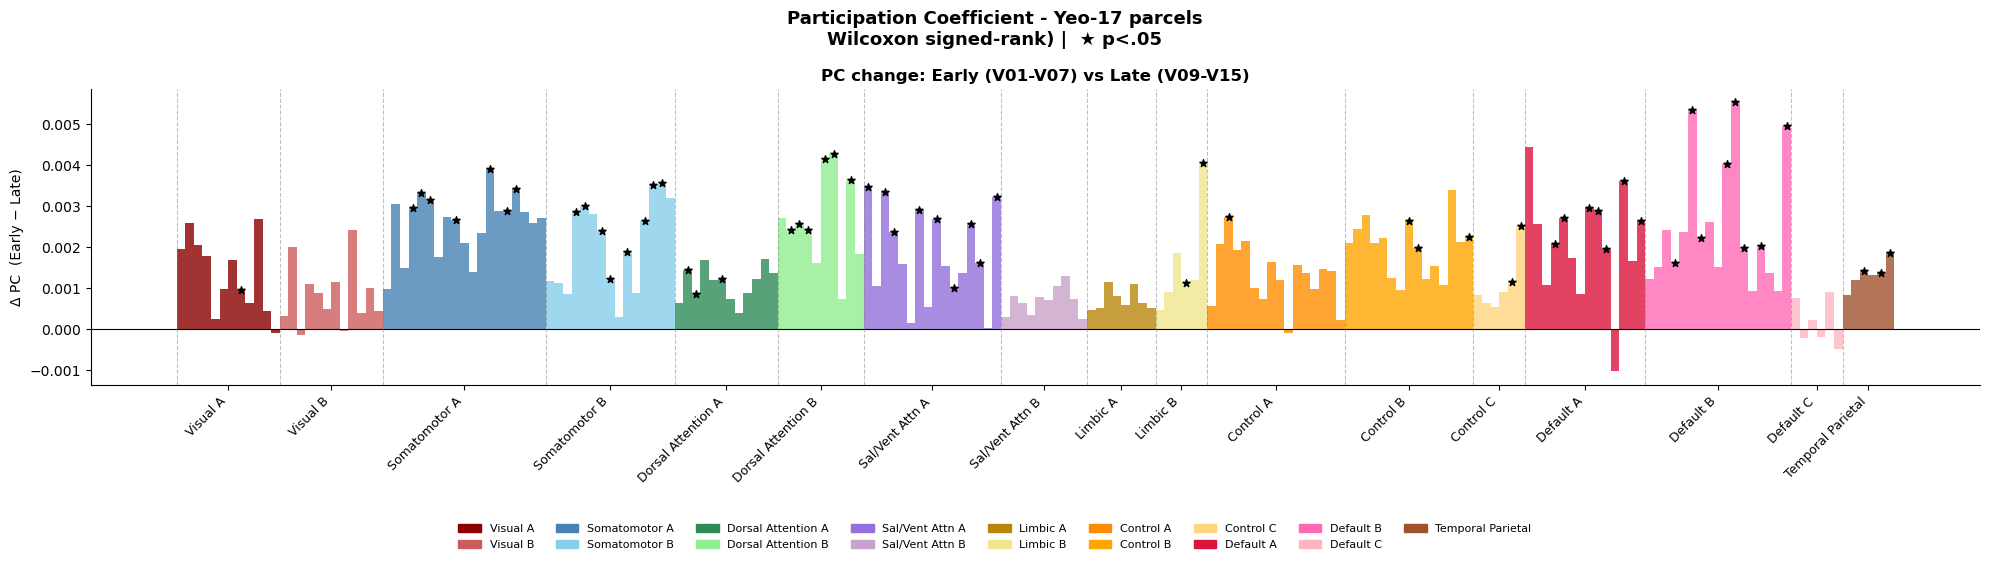

In [16]:
# ── Plot 2: Late vs Early ──────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(20, 5))

effect    = eff_epoch[sort_idx17]
pvals_fdr = pfdr_epoch[sort_idx17]
sig       = pvals_fdr < 0.05

ax2.bar(x, effect, color=colors17, width=1.0, linewidth=0, alpha=0.8)
ax2.axhline(0, color="black", linewidth=0.8)

for b in boundaries17:
    ax2.axvline(b - 0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

sig_x = np.where(sig)[0]
ax2.scatter(sig_x, effect[sig_x], marker="*", color="black", s=30, zorder=5)

ax2.set_xticks(net_centers17)
ax2.set_xticklabels(net_labels17, rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Δ PC  (Early − Late)", fontsize=10)
ax2.set_title(
    "PC change: Early (V01-V07) vs Late (V09-V15)",
    fontsize=12, fontweight="bold"
)
ax2.spines[["top", "right"]].set_visible(False)

fig2.legend(handles=legend_els, loc="lower center",
            ncol=9, fontsize=8, frameon=False,
            bbox_to_anchor=(0.5, -0.12))

fig2.suptitle(
    "Participation Coefficient - Yeo-17 parcels\n"
    "Wilcoxon signed-rank) |  ★ p<.05",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pc_yeo17_parcel_wilcoxon_time.png"), dpi=300, bbox_inches="tight")
plt.show()

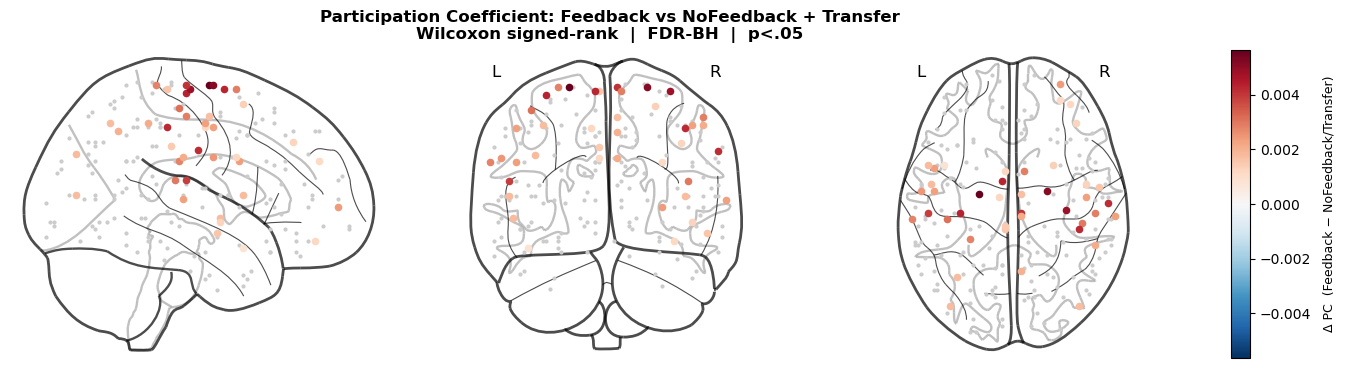

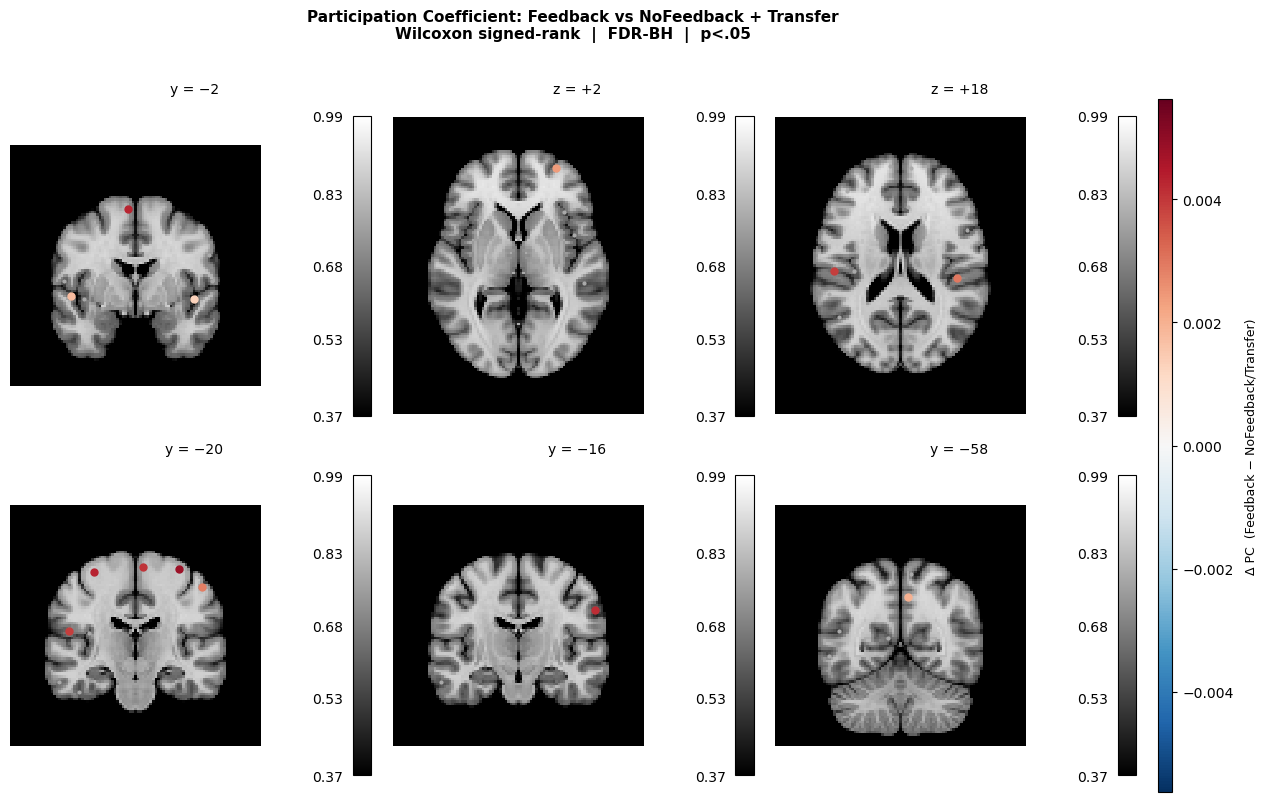

In [17]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from nilearn import plotting, datasets

# ── Load coordinates ───────────────────────────────────────────────────────────
PATH_COORDS = "../utils/matched_labels_exact.csv"
coords_df = pd.read_csv(PATH_COORDS)

def extract_yeo17_network(label):
    label = re.sub(r'^17Networks_[LR]H_', '', label)
    for net in YEO17_ORDER:
        if label.startswith(net):
            return net
    return None

coords_df['yeo17_network'] = coords_df['label_df2'].apply(extract_yeo17_network)

cortical_coords = (
    coords_df[coords_df['yeo17_network'].notna()]
    .sort_values('ROI Label')
    .reset_index(drop=True)
)

assert len(cortical_coords) == N_PARC17, (
    f"Coord count ({len(cortical_coords)}) ≠ N_PARC17 ({N_PARC17}) — "
    "check that the CSV and Yeo-17 CSV use the same parcellation."
)

mni_coords   = cortical_coords[['R', 'A', 'S']].values   # (N_PARC17, 3)
mni_template = datasets.load_mni152_template(resolution=2)

# ── Slice layout matching the paper (mode, coordinate, label) ─────────────────
PAPER_SLICES = [
    ('y', -2,  'y = −2'),
    ('z',  2,  'z = +2'),
    ('z', 18,  'z = +18'),
    ('y', -20, 'y = −20'),
    ('y', -16, 'y = −16'),
    ('y', -58, 'y = −58'),
]

# ── Main plotting function ─────────────────────────────────────────────────────
def brain_parcel_plot(effect, pfdr, title, cbar_label, out_stem, vmax=None):

    sig = pfdr < 0.05

    if not sig.any():
        print(f"No significant parcels for: {title}")
        return

    if vmax is None:
        vmax = np.nanpercentile(np.abs(effect[sig]), 99)

    cmap      = cm.RdBu_r
    norm      = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    sig_colors = [mcolors.to_hex(cmap(norm(e))) for e in effect[sig]]

    # ── Figure 1: glass brain (3 projections) ─────────────────────────────────
    fig1 = plt.figure(figsize=(16, 4))
    gs1  = GridSpec(1, 4, figure=fig1, width_ratios=[1, 1, 1, 0.05], wspace=0.1)
    axes1 = [fig1.add_subplot(gs1[0, i]) for i in range(3)]
    cax1  =  fig1.add_subplot(gs1[0, 3])

    for ax, mode in zip(axes1, ['x', 'y', 'z']):
        disp = plotting.plot_glass_brain(
            None, display_mode=mode, figure=fig1, axes=ax, black_bg=False
        )
        if (~sig).any():
            disp.add_markers(mni_coords[~sig], marker_color='#cccccc', marker_size=4)
        for coord_xyz, color in zip(mni_coords[sig], sig_colors):
            disp.add_markers(coord_xyz.reshape(1, 3), marker_color=color, marker_size=20)

    sm1 = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm1.set_array([])
    fig1.colorbar(sm1, cax=cax1, orientation='vertical')
    cax1.set_ylabel(cbar_label, fontsize=9, labelpad=8)
    fig1.suptitle(
        f"{title}\nWilcoxon signed-rank  |  FDR-BH  |  p<.05",
        fontsize=12, fontweight='bold',
    )
    plt.savefig(os.path.join(FIGURES_DIR, f"{out_stem}_glass.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # ── Figure 2: mixed coronal/axial slices (2 × 3 grid) ────────────────────
    fig2 = plt.figure(figsize=(15, 9))
    gs2  = GridSpec(2, 4, figure=fig2,
                    width_ratios=[1, 1, 1, 0.04],
                    hspace=0.08, wspace=0.05)
    axes2 = [fig2.add_subplot(gs2[row, col])
             for row in range(2) for col in range(3)]
    cax2  =  fig2.add_subplot(gs2[:, 3])

    for ax, (mode, coord, label) in zip(axes2, PAPER_SLICES):
        disp = plotting.plot_anat(
            mni_template,
            display_mode=mode,
            cut_coords=[coord],
            figure=fig2, axes=ax,
            black_bg=False, annotate=False, dim=-0.5,
        )
        if (~sig).any():
            disp.add_markers(mni_coords[~sig], marker_color='#aaaaaa', marker_size=4)
        for coord_xyz, color in zip(mni_coords[sig], sig_colors):
            disp.add_markers(coord_xyz.reshape(1, 3), marker_color=color, marker_size=25)
        ax.set_title(label, fontsize=10, pad=4)

    sm2 = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm2.set_array([])
    fig2.colorbar(sm2, cax=cax2, orientation='vertical')
    cax2.set_ylabel(cbar_label, fontsize=9, labelpad=8)
    fig2.suptitle(
        f"{title}\nWilcoxon signed-rank  |  FDR-BH  |  p<.05",
        fontsize=11, fontweight='bold',
    )
    plt.savefig(os.path.join(FIGURES_DIR, f"{out_stem}_slices.png"), dpi=300, bbox_inches='tight')
    plt.show()


# ── Run for both contrasts ─────────────────────────────────────────────────────
brain_parcel_plot(
    eff_cond, pfdr_cond,
    title="Participation Coefficient: Feedback vs NoFeedback + Transfer",
    cbar_label="Δ PC  (Feedback − NoFeedback/Transfer)",
    out_stem="pc_brain_condition",
)

In [18]:
def describe_sig_parcels(effect, pfdr, cortical_coords, label, save_csv=True):
    sig = pfdr < 0.05
    if not sig.any():
        print(f"\n{label}: no significant increasing parcels")
        return
    
    result = cortical_coords[sig].copy()
    result['effect'] = effect[sig]
    result['pfdr']   = pfdr[sig]
    result = result.sort_values('effect', ascending=False)
    
    if save_csv:
        filename = label.replace(' ', '_').replace('/', '_') + '_sig_parcels.csv'
        result[['ROI Name', 'label_df2', 'yeo17_network',
                'R', 'A', 'S', 'effect', 'pfdr']].to_csv(filename, index=False)
        print(f"Saved: {filename}")

describe_sig_parcels(eff_cond,  pfdr_cond,  cortical_coords,
                     "Feedback vs NoFeedback+Transfer")

Saved: Feedback_vs_NoFeedback+Transfer_sig_parcels.csv


In [19]:
import numpy as np

sig_mask = (pfdr_cond < 0.05) & (eff_cond > 0)
sig_coords = cortical_coords[sig_mask][['R', 'A', 'S']].copy()
sig_coords.columns = ['x', 'y', 'z']

print("── Z distribution (axial slices) ──────────────────")
bins_z = np.arange(-30, 80, 10)
counts_z, edges_z = np.histogram(sig_coords['z'], bins=bins_z)
for i, c in enumerate(counts_z):
    if c > 0:
        print(f"  z = {edges_z[i]:+3.0f} to {edges_z[i+1]:+3.0f}:  {c} parcels  {'█'*c}")

print("\n── Y distribution (coronal slices) ────────────────")
bins_y = np.arange(-70, 70, 10)
counts_y, edges_y = np.histogram(sig_coords['y'], bins=bins_y)
for i, c in enumerate(counts_y):
    if c > 0:
        print(f"  y = {edges_y[i]:+3.0f} to {edges_y[i+1]:+3.0f}:  {c} parcels  {'█'*c}")

print("\n── All parcel coordinates (x, y, z) ───────────────")
print(sig_coords.sort_values('z', ascending=False).to_string())

── Z distribution (axial slices) ──────────────────
  z = -20 to -10:  2 parcels  ██
  z = -10 to  +0:  3 parcels  ███
  z =  +0 to +10:  2 parcels  ██
  z = +10 to +20:  4 parcels  ████
  z = +20 to +30:  3 parcels  ███
  z = +30 to +40:  7 parcels  ███████
  z = +40 to +50:  7 parcels  ███████
  z = +50 to +60:  4 parcels  ████
  z = +60 to +70:  9 parcels  █████████

── Y distribution (coronal slices) ────────────────
  y = -70 to -60:  1 parcels  █
  y = -60 to -50:  1 parcels  █
  y = -50 to -40:  1 parcels  █
  y = -40 to -30:  3 parcels  ███
  y = -30 to -20:  10 parcels  ██████████
  y = -20 to -10:  4 parcels  ████
  y = -10 to  +0:  9 parcels  █████████
  y =  +0 to +10:  6 parcels  ██████
  y = +30 to +40:  1 parcels  █
  y = +40 to +50:  2 parcels  ██
  y = +50 to +60:  1 parcels  █

── All parcel coordinates (x, y, z) ───────────────
      x   y   z
26  -26 -38  68
27  -20 -10  68
132   6 -22  68
130  22  -8  68
28   -4 -32  66
53   -6  -2  66
157   8   4  66
128  34 -20  

In [20]:
# Run this to see which parcels appear near y = -2
sig_mask = (pfdr_cond < 0.05) & (eff_cond > 0)
near_slice = cortical_coords[sig_mask].copy()
near_slice['effect'] = eff_cond[sig_mask]
near_slice = near_slice[near_slice['A'].between(-12, 8)]  # within ~10mm of y=-2
print(near_slice[['ROI Name', 'label_df2', 'R', 'A', 'S', 'effect']].sort_values('A').to_string())

                                 ROI Name                            label_df2   R   A   S    effect
21                  7Networks_LH_SomMot_8              17Networks_LH_SomMotA_1  -8 -12  46  0.001203
124                7Networks_RH_SomMot_10              17Networks_RH_SomMotA_2  46 -12  48  0.002319
125                7Networks_RH_SomMot_11              17Networks_RH_SomMotA_3   6 -10  52  0.001698
27                 7Networks_LH_SomMot_14              17Networks_LH_SomMotA_6 -20 -10  68  0.005956
20                  7Networks_LH_SomMot_7         17Networks_LH_SomMotB_Cent_2 -48  -8  46  0.002322
130                7Networks_RH_SomMot_16              17Networks_RH_SomMotA_8  22  -8  68  0.005138
19                  7Networks_LH_SomMot_6         17Networks_LH_SomMotB_Cent_1 -56  -8  30  0.002486
186           7Networks_RH_Default_Temp_3              17Networks_RH_TempPar_1  54  -6 -10  0.001554
152  7Networks_RH_SalVentAttn_FrOperIns_2     17Networks_RH_SalVentAttnA_Ins_2  46  -4  -4 

Significant parcels:
  Early vs Late only          : 40
  Condition only              : 21
  Both                        : 20


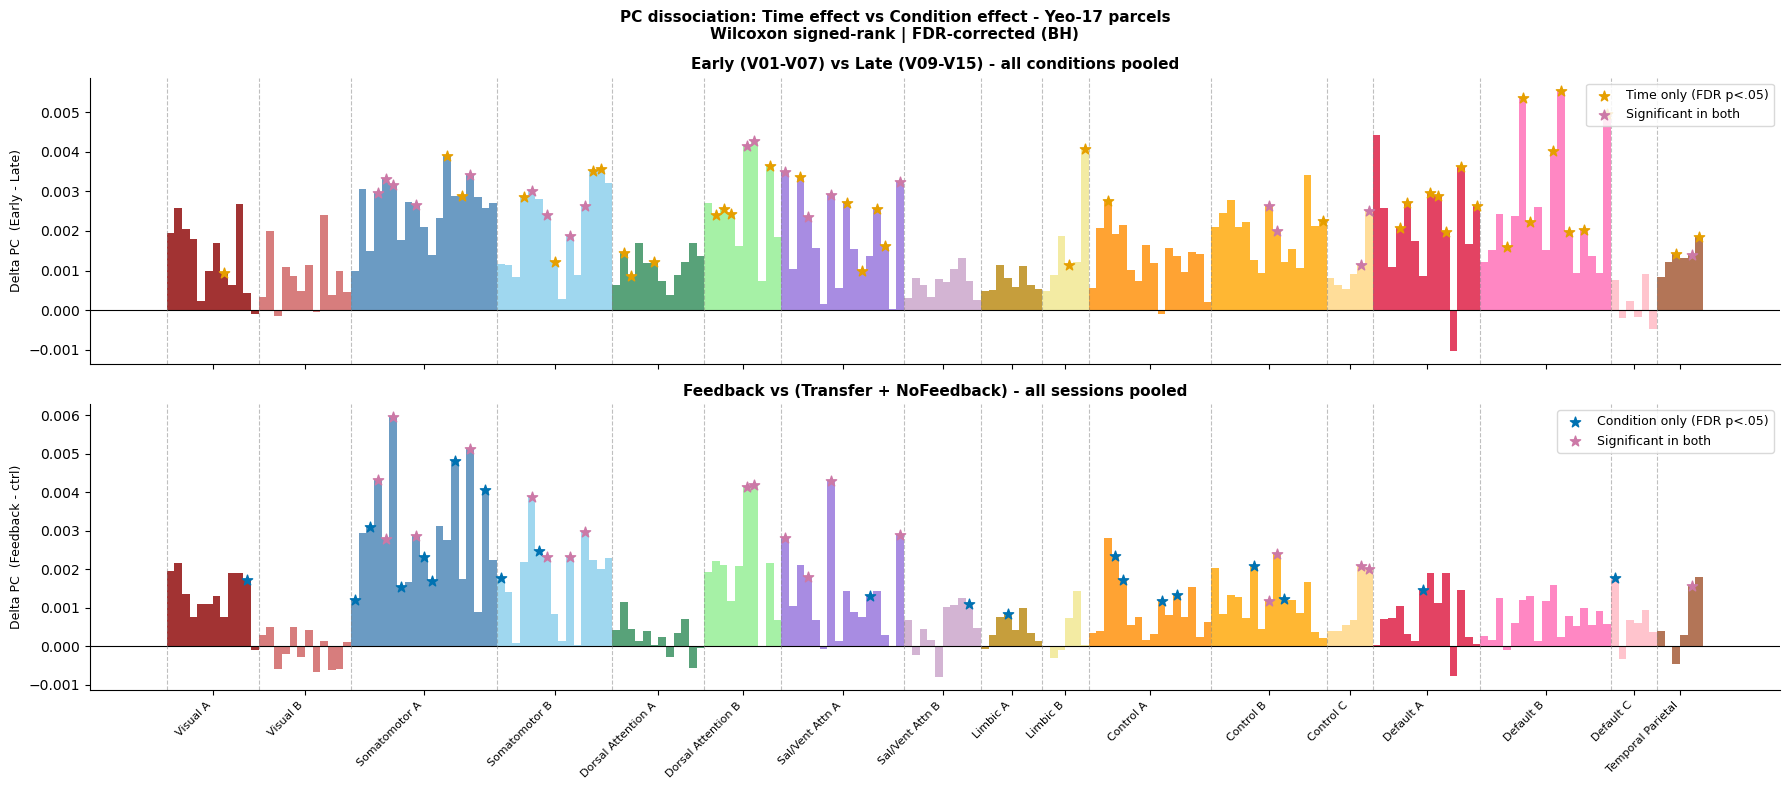

In [21]:
# ── Dissociation: Time (V01-V05 vs V10-V15) x Condition (FB vs ctrl) ──────────
# Early = V01-V05, Late = V11-V15 (all conditions pooled)
EARLY_D = [SESSIONS.index(s) for s in ["V01", "V02", "V03", "V04", "V05", "V06", "V07"]]
LATE_D  = [SESSIONS.index(s) for s in ["V09", "V10", "V11", "V12", "V13", "V14", "V15"]]

mu17_early_d = np.nanmean(pc17_all[:, EARLY_D, :], axis=1)
mu17_late_d  = np.nanmean(pc17_all[:, LATE_D,  :], axis=1)

eff_epoch_d, pfdr_epoch_d = parcel_wilcoxon17(mu17_early_d, mu17_late_d)

# ── Significance masks ────────────────────────────────────────────────────────
sig_epoch = pfdr_epoch_d < 0.05   # early vs late
sig_cond  = pfdr_cond   < 0.05   # feedback vs (transfer + no feedback)

only_epoch = sig_epoch & ~sig_cond   # time effect only
only_cond  = sig_cond  & ~sig_epoch  # condition effect only
both       = sig_epoch &  sig_cond   # shared

print(f"Significant parcels:")
print(f"  Early vs Late only          : {only_epoch.sum()}")
print(f"  Condition only              : {only_cond.sum()}")
print(f"  Both                        : {both.sum()}")

# ── Sort ──────────────────────────────────────────────────────────────────────
eff_epoch_s  = eff_epoch_d[sort_idx17]
eff_cond_s   = eff_cond[sort_idx17]
only_epoch_s = only_epoch[sort_idx17]
only_cond_s  = only_cond[sort_idx17]
both_s       = both[sort_idx17]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

for ax, effect, excl_mask, title, ylabel, excl_color, excl_label in [
    (axes[0],
     eff_epoch_s, only_epoch_s,
     "Early (V01-V07) vs Late (V09-V15) - all conditions pooled",
     "Delta PC  (Early - Late)",
     "#E69F00",
     "Time only (FDR p<.05)"),
    (axes[1],
     eff_cond_s, only_cond_s,
     "Feedback vs (Transfer + NoFeedback) - all sessions pooled",
     "Delta PC  (Feedback - ctrl)",
     "#0072B2",
     "Condition only (FDR p<.05)"),
]:
    ax.bar(np.arange(N_PARC17), effect, color=colors17,
           width=1.0, linewidth=0, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)

    for b in boundaries17:
        ax.axvline(b - 0.5, color="gray", linewidth=0.8,
                   linestyle="--", alpha=0.5)

    # Parcels significant in this comparison only
    excl_x = np.where(excl_mask)[0]
    ax.scatter(excl_x, effect[excl_x],
               marker="*", color=excl_color, s=60, zorder=5,
               label=excl_label)

    # Parcels significant in both comparisons
    both_x = np.where(both_s)[0]
    ax.scatter(both_x, effect[both_x],
               marker="*", color="#CC79A7", s=60, zorder=5,
               label="Significant in both")

    ax.set_xticks(net_centers17)
    ax.set_xticklabels(net_labels17, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=9, loc="upper right", frameon=True,
              framealpha=0.85, edgecolor="lightgray")

fig.suptitle(
    "PC dissociation: Time effect vs Condition effect - Yeo-17 parcels\n"
    "Wilcoxon signed-rank | FDR-corrected (BH)",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pc_yeo17_dissociation.png"), dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# ── Brain plots for dissociation sets ────────────────────────────────────────
# Reuses: cortical_coords, mni_coords, mni_template, cm, mcolors, GridSpec,
#         plotting — all defined in cell 14
# Reuses: only_epoch, only_cond, both, eff_epoch_d, pfdr_epoch_d,
#         eff_cond, pfdr_cond — all defined in cell 13

def peak_coords(vals, n=3, bin_size=10):
    if len(vals) == 0:
        return []
    bins = np.arange(vals.min() - 5, vals.max() + 15, bin_size)
    counts, edges = np.histogram(vals, bins=bins)
    top_bins = np.argsort(counts)[::-1][:n]
    return sorted([int(0.5 * (edges[i] + edges[i+1])) for i in top_bins])

def brain_parcel_plot_mask(mask, effect, title, cbar_label, out_stem,
                           slices=None, vmax=None):  # ← add slices parameter
    plot_mask = mask

    if not plot_mask.any():
        print(f"No parcels to plot for: {title}")
        return

    if vmax is None:
        vmax = np.nanpercentile(np.abs(effect[plot_mask]), 99)

    # Auto-select if not provided
    if slices is None:
        sig_z = cortical_coords[plot_mask]['S'].values
        sig_y = cortical_coords[plot_mask]['A'].values
        slices = (
            [('z', z, f'z = {z:+d}') for z in peak_coords(sig_z, n=3)] +
            [('y', y, f'y = {y:+d}') for y in peak_coords(sig_y, n=3)]
        )

    # ... rest of function unchanged ...

    cmap       = cm.RdBu_r
    norm       = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    sig_colors = [mcolors.to_hex(cmap(norm(e))) for e in effect[plot_mask]]


    # ── Glass brain ───────────────────────────────────────────────────────────
    fig1 = plt.figure(figsize=(16, 4))
    gs1  = GridSpec(1, 4, figure=fig1, width_ratios=[1, 1, 1, 0.05], wspace=0.1)
    axes1 = [fig1.add_subplot(gs1[0, i]) for i in range(3)]
    cax1  =  fig1.add_subplot(gs1[0, 3])

    for ax, mode in zip(axes1, ['x', 'y', 'z']):
        disp = plotting.plot_glass_brain(
            None, display_mode=mode, figure=fig1, axes=ax, black_bg=False
        )
        if (~plot_mask).any():
            disp.add_markers(mni_coords[~plot_mask], marker_color='#cccccc', marker_size=4)
        for coord_xyz, color in zip(mni_coords[plot_mask], sig_colors):
            disp.add_markers(coord_xyz.reshape(1, 3), marker_color=color, marker_size=20)

    sm1 = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm1.set_array([])
    fig1.colorbar(sm1, cax=cax1, orientation='vertical')
    cax1.set_ylabel(cbar_label, fontsize=9, labelpad=8)
    fig1.suptitle(f"{title}\nWilcoxon  |  FDR-BH  |  p<.05",
                  fontsize=12, fontweight='bold')
    plt.savefig(os.path.join(FIGURES_DIR, f"{out_stem}_glass.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # ── Slices ────────────────────────────────────────────────────────────────
    fig2 = plt.figure(figsize=(15, 9))
    gs2  = GridSpec(2, 4, figure=fig2,
                    width_ratios=[1, 1, 1, 0.04], hspace=0.08, wspace=0.05)
    axes2 = [fig2.add_subplot(gs2[row, col])
             for row in range(2) for col in range(3)]
    cax2  =  fig2.add_subplot(gs2[:, 3])

    for ax, (mode, coord, label) in zip(axes2, slices):
        disp = plotting.plot_anat(
            mni_template, display_mode=mode, cut_coords=[coord],
            figure=fig2, axes=ax, black_bg=False, annotate=False, dim=-0.5,
        )
        if (~plot_mask).any():
            disp.add_markers(mni_coords[~plot_mask], marker_color='#aaaaaa', marker_size=4)
        for coord_xyz, color in zip(mni_coords[plot_mask], sig_colors):
            disp.add_markers(coord_xyz.reshape(1, 3), marker_color=color, marker_size=25)
        ax.set_title(label, fontsize=10, pad=4)

    sm2 = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm2.set_array([])
    fig2.colorbar(sm2, cax=cax2, orientation='vertical')
    cax2.set_ylabel(cbar_label, fontsize=9, labelpad=8)
    fig2.suptitle(f"{title}\nWilcoxon  |  FDR-BH  |  p<.05",
                  fontsize=11, fontweight='bold')
    plt.savefig(os.path.join(FIGURES_DIR, f"{out_stem}_slices.png"), dpi=300, bbox_inches='tight')
    plt.show()

In [23]:
# ── Save dissociation parcel lists as CSVs ────────────────────────────────────

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

def save_dissociation_csv(mask, effect, pfdr, filename):
    plot_mask = mask
    if not plot_mask.any():
        print(f"No parcels for: {filename}")
        return
    result = cortical_coords[plot_mask].copy()
    result['effect'] = effect[plot_mask]
    result['pfdr']   = pfdr[plot_mask]
    result = result.sort_values('effect', ascending=False)
    result[['ROI Name', 'label_df2', 'yeo17_network',
            'R', 'A', 'S', 'effect', 'pfdr']].to_csv(filename, index=False)
    print(f"Saved {plot_mask.sum()} parcels → {filename}")

save_dissociation_csv(
    only_cond, eff_cond, pfdr_cond,
    "pure_condition_parcels.csv"
)
save_dissociation_csv(
    only_epoch, eff_epoch_d, pfdr_epoch_d,
    "pure_epoch_parcels.csv"
)
save_dissociation_csv(
    both, eff_cond, pfdr_cond,
    "confounded_parcels.csv"
)

Saved 21 parcels → pure_condition_parcels.csv
Saved 40 parcels → pure_epoch_parcels.csv
Saved 20 parcels → confounded_parcels.csv


In [24]:
import nibabel as nib

# ── Load atlas once ───────────────────────────────────────────────────────────
_atlas_img  = nib.load('../utils/Schaefer2018_200Parcels_17Networks_order_FSLMNI152_2mm.nii.gz')
_atlas_data = np.asarray(_atlas_img.dataobj, dtype=int)


def _make_overlay(mask, effect):
    """Build a stat-map volume: each significant parcel filled with its effect size."""
    vol = np.zeros(_atlas_data.shape, dtype=float)
    for idx in np.where(mask)[0]:
        label = int(cortical_coords.iloc[idx]['ROI Label'])
        vol[_atlas_data == label] = effect[idx]
    return nib.Nifti1Image(vol, _atlas_img.affine, _atlas_img.header)


def brain_parcel_plot_patches(mask, effect, title, cbar_label, out_stem,
                              slices=None, vmax=None):
    plot_mask = mask
    if not plot_mask.any():
        print(f"No parcels to plot for: {title}")
        return

    if vmax is None:
        vmax = np.nanpercentile(np.abs(effect[plot_mask]), 99)

    overlay_img = _make_overlay(plot_mask, effect)
    subtitle = "Wilcoxon  |  FDR-BH  |  p<.05"

    # ── Glass brain (4 views) ─────────────────────────────────────────────────
    plotting.plot_glass_brain(
        overlay_img,
        colorbar=True, vmax=vmax, threshold=1e-9,
        display_mode='lyrz', cmap='Reds',
        figure=plt.figure(figsize=(16, 4)),
        title=f"{title}\n{subtitle}",
    )
    plt.savefig(os.path.join(FIGURES_DIR, f"{out_stem}_glass.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # ── Anatomical slices ─────────────────────────────────────────────────────
    if slices is None:
        z_cuts = sorted(peak_coords(cortical_coords[plot_mask]['S'].values, n=3))
        y_cuts = sorted(peak_coords(cortical_coords[plot_mask]['A'].values, n=3))
    else:
        z_cuts = [c for mode, c, _ in slices if mode == 'z']
        y_cuts = [c for mode, c, _ in slices if mode == 'y']

    for mode, cuts, orient in [('z', z_cuts, 'axial'), ('y', y_cuts, 'coronal')]:
        if not cuts:
            continue
        plotting.plot_stat_map(
            overlay_img, bg_img=mni_template,
            display_mode=mode, cut_coords=cuts,
            threshold=1e-9, vmax=vmax, cmap='RdBu_r',
            colorbar=True, symmetric_cbar=True, annotate=True, dim=-0.5,
            black_bg=False,
            figure=plt.figure(figsize=(5 * len(cuts), 5)),
            title=f"{title} — {orient}\n{subtitle}",
        )
        plt.savefig(os.path.join(FIGURES_DIR, f"{out_stem}_slices_{mode}.png"), dpi=300, bbox_inches='tight')
        plt.show()

Auditory parcels in mask:
  17Networks_LH_SomMotB_Aud_1  effect=0.00178
  17Networks_RH_SomMotB_Aud_2  effect=0.00233


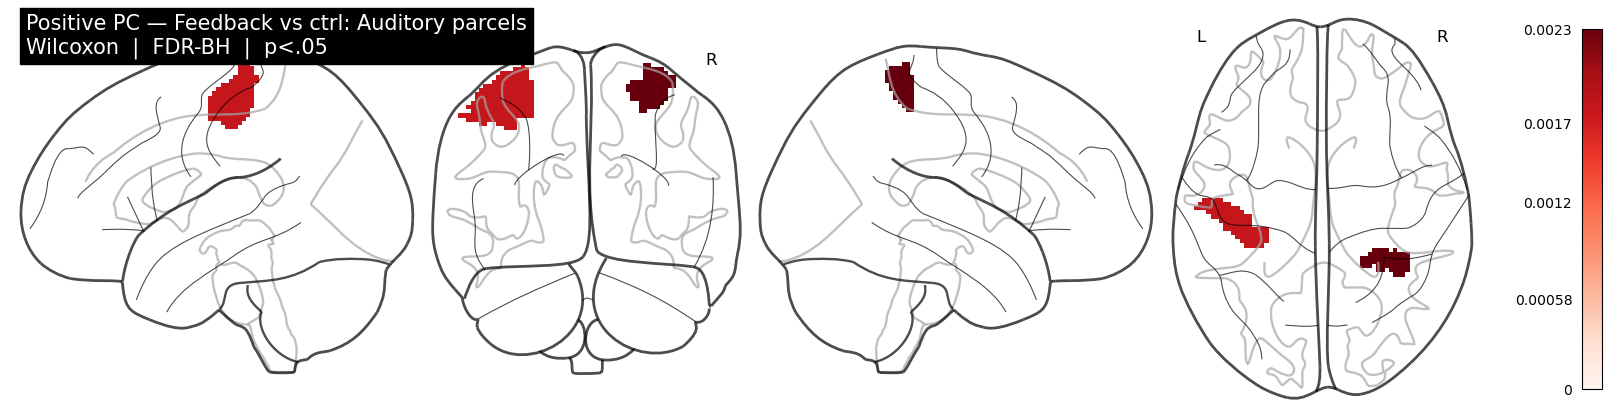

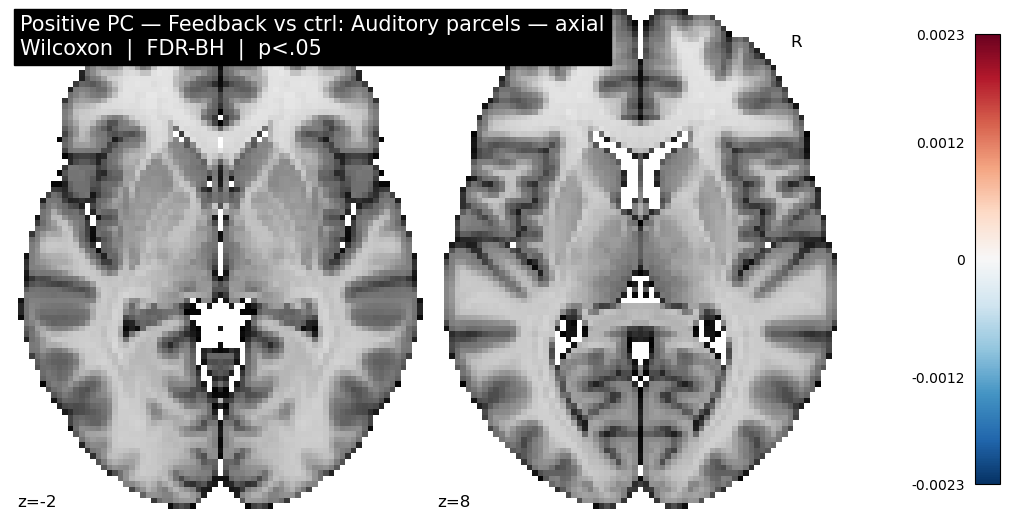

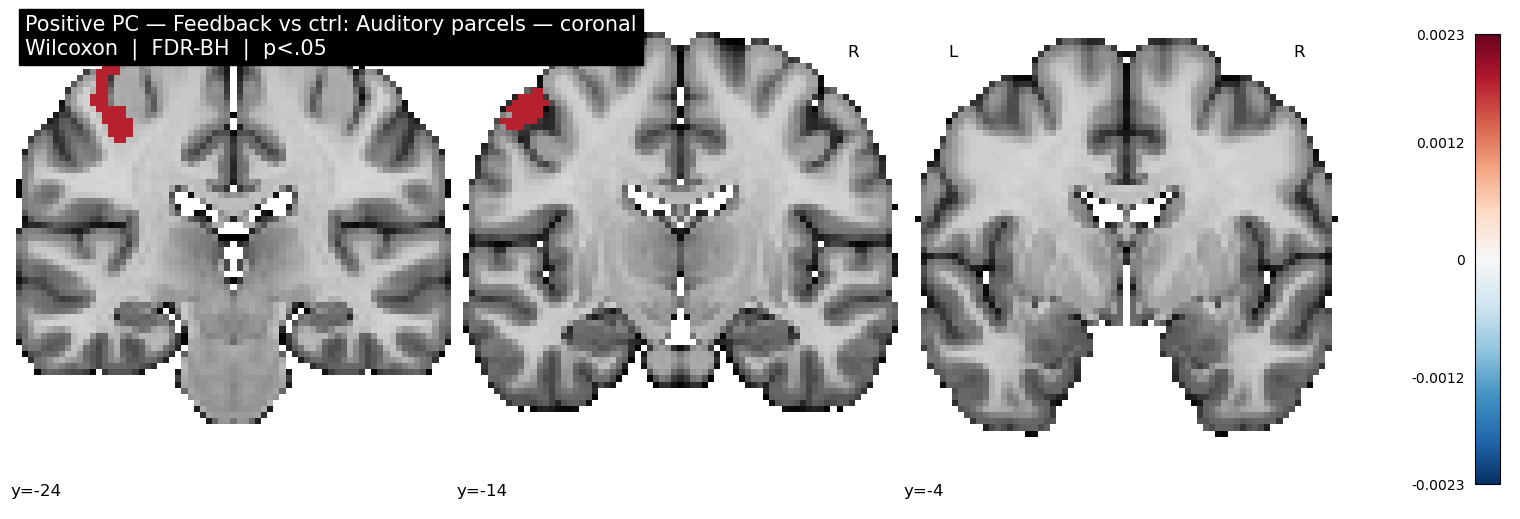

In [25]:
# label17_map already defined above

roi_names = np.array([
    label17_map.get(cortical_parcel_nums[p] + 1, "Unknown")
    for p in range(N_PARC17)
])

sig_cond = pfdr_cond < 0.05
mask_aud = sig_cond & np.array(["_Aud_" in n for n in roi_names])

print("Auditory parcels in mask:")
for p in np.where(mask_aud)[0]:
    print(f"  {roi_names[p]}  effect={eff_cond[p]:.5f}")

brain_parcel_plot_patches(
    mask_aud, eff_cond,
    title="Positive PC — Feedback vs ctrl: Auditory parcels",
    cbar_label="Δ PC (Feedback − ctrl)",
    out_stem="pc_pos_cond_auditory",
)


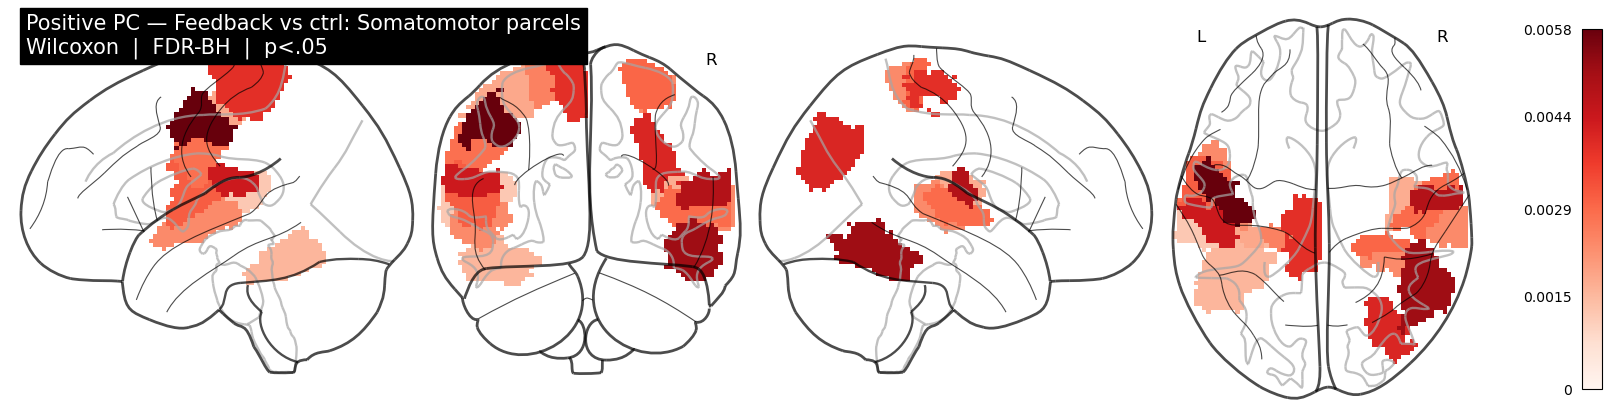

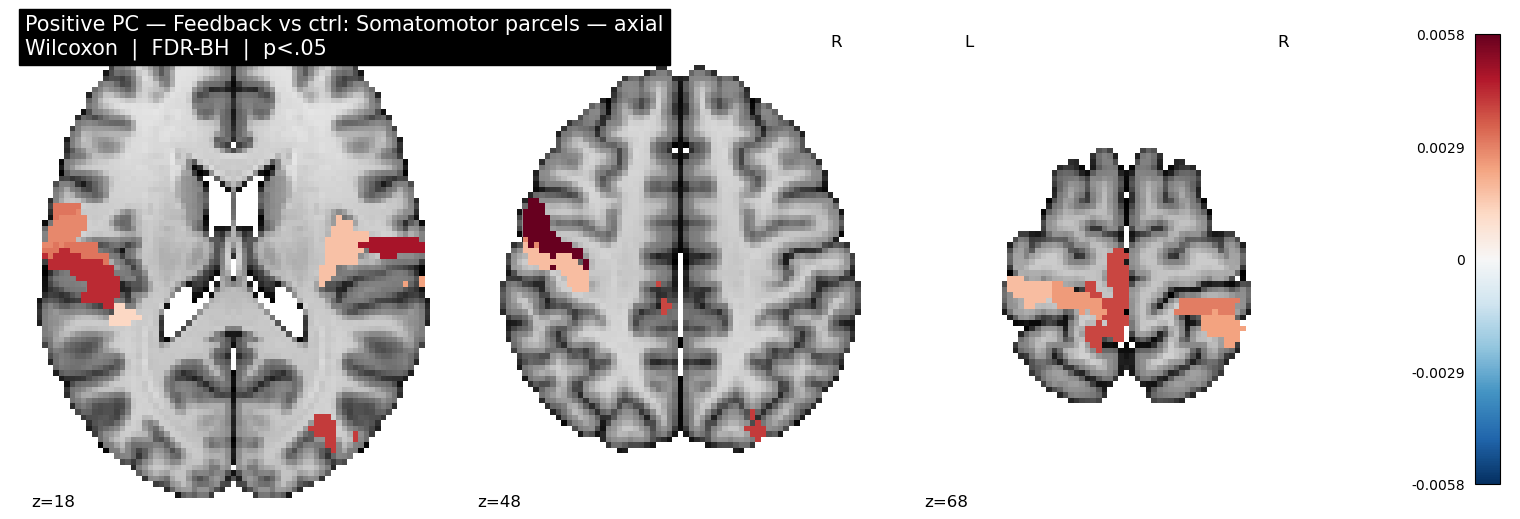

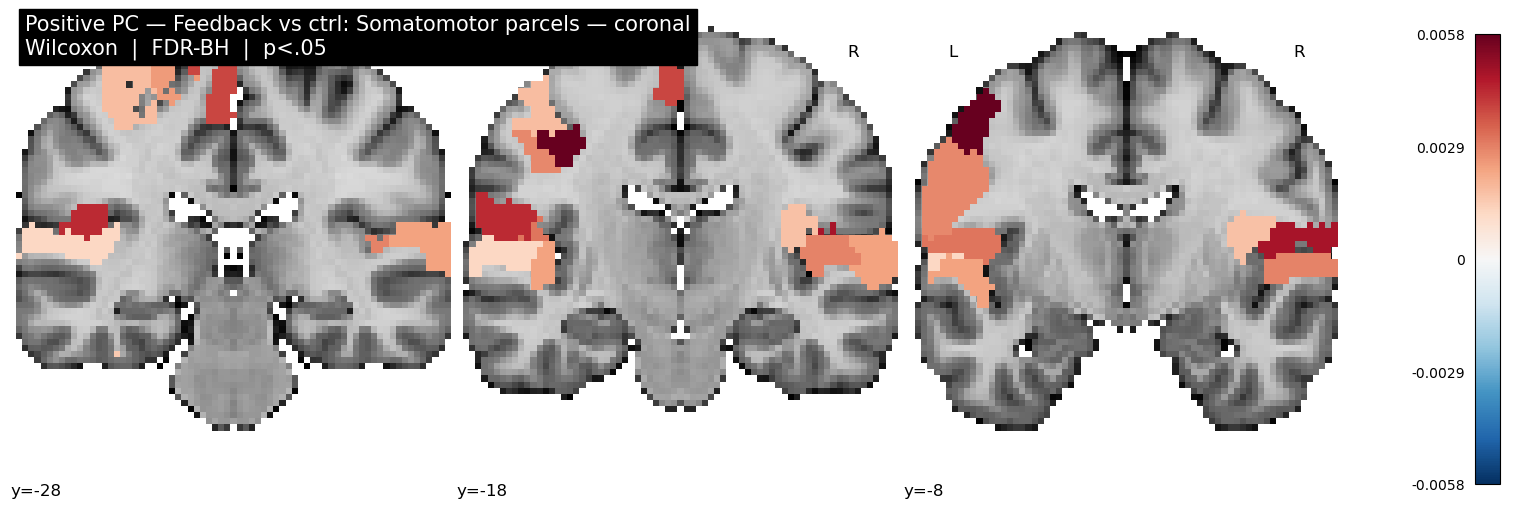

In [26]:
mask_somemot = sig_cond & np.isin(net17_labels, ["SomMotA", "SomMotB"])

brain_parcel_plot_patches(
    mask_somemot, eff_cond,
    title="Positive PC — Feedback vs ctrl: Somatomotor parcels",
    cbar_label="Δ PC (Feedback − ctrl)",
    out_stem="pc_pos_cond_somemot",
)


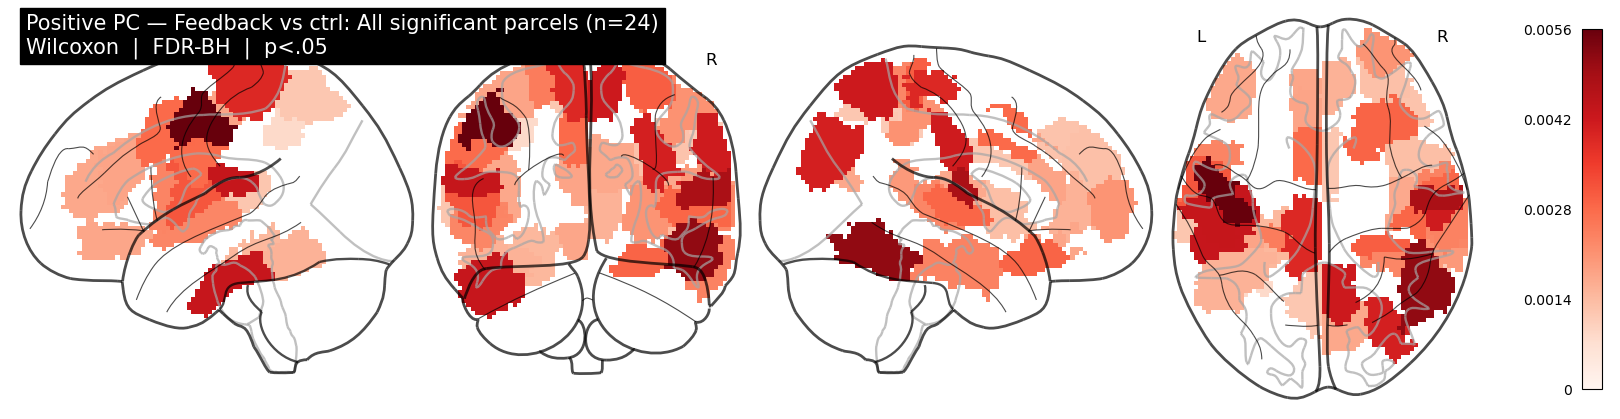

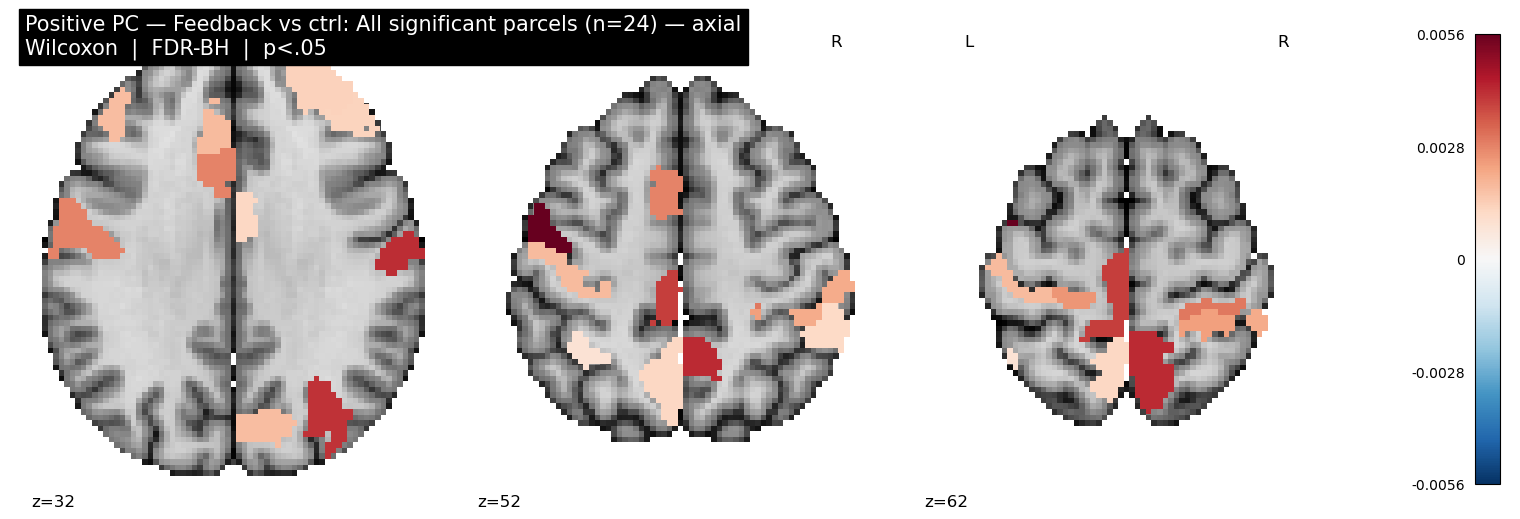

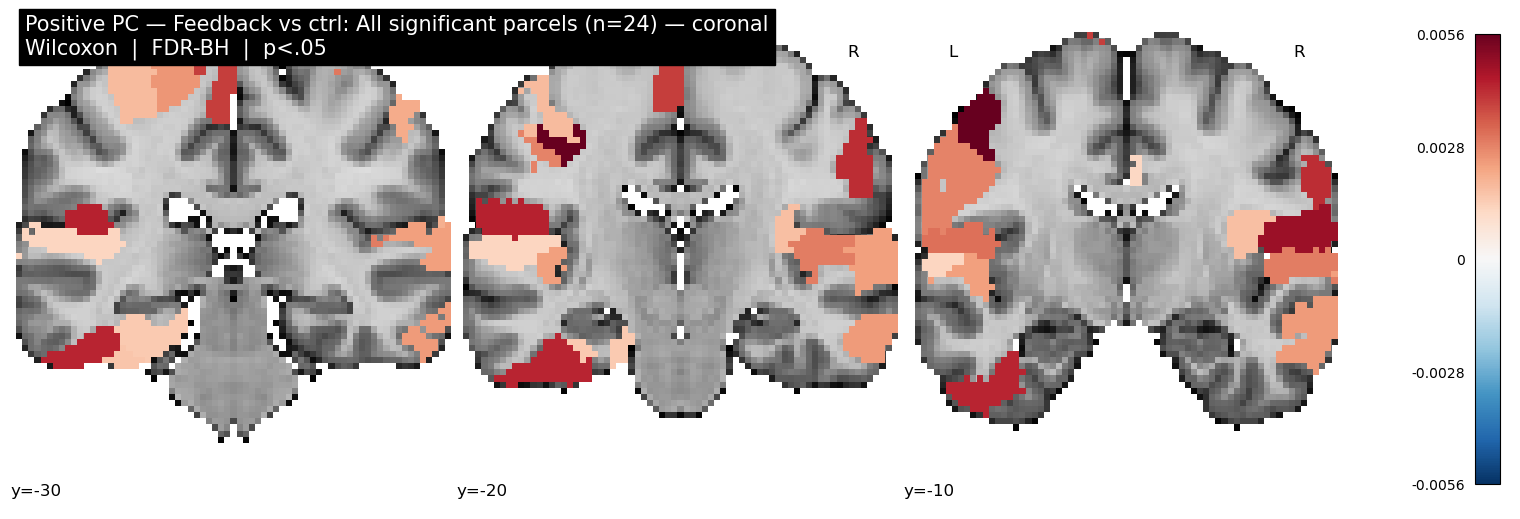

In [27]:
brain_parcel_plot_patches(
    sig_cond, eff_cond,
    title="Positive PC — Feedback vs ctrl: All significant parcels (n=24)",
    cbar_label="Δ PC (Feedback − ctrl)",
    out_stem="pc_pos_cond_all",
)


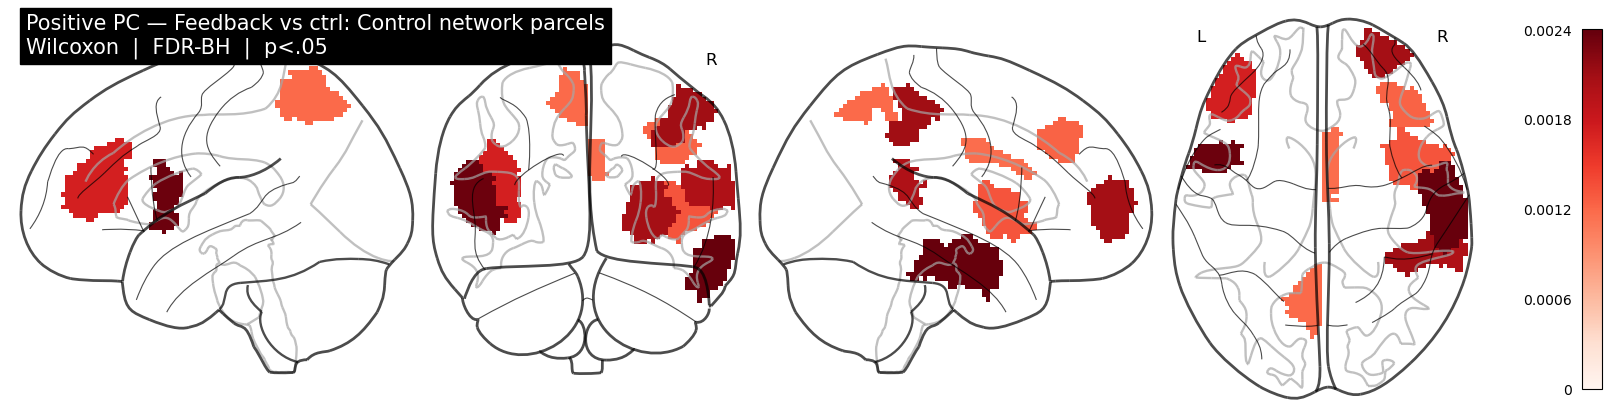

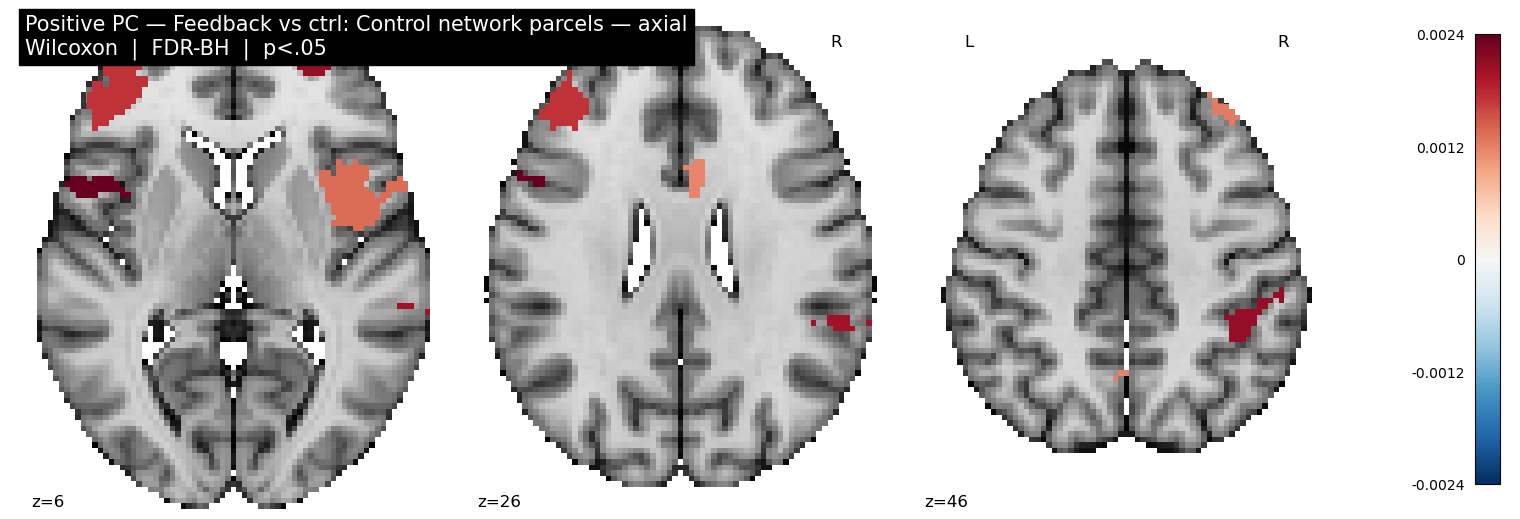

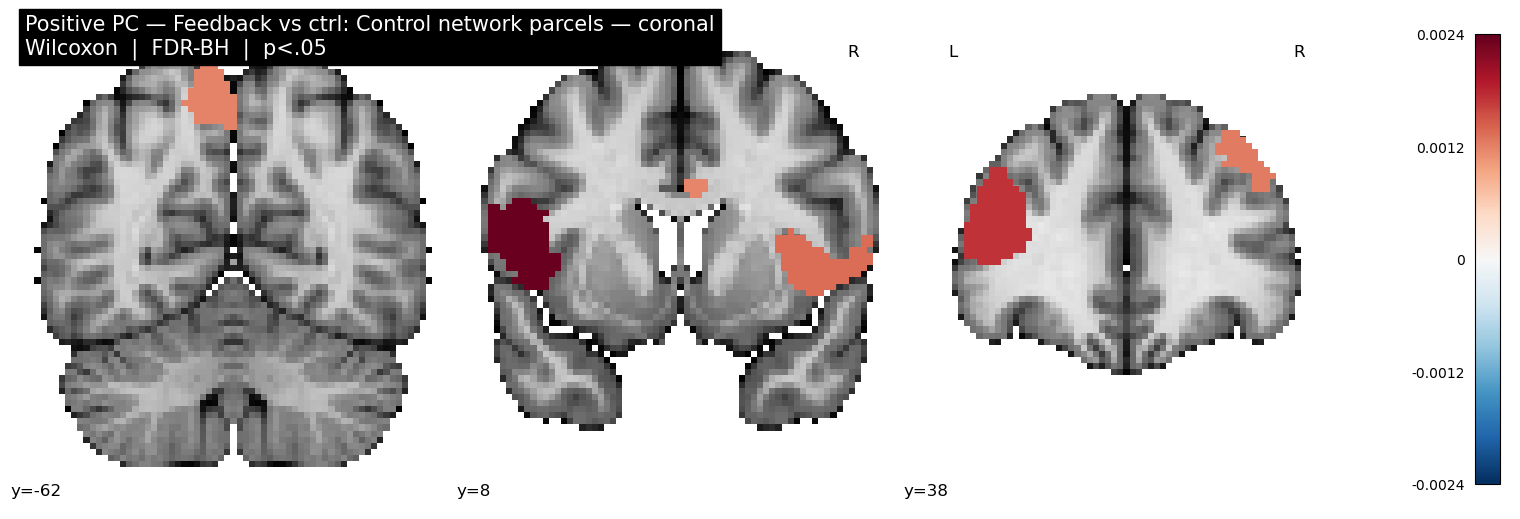

In [28]:
mask_control = sig_cond & np.isin(net17_labels, ["ContA", "ContB", "ContC"])

brain_parcel_plot_patches(
    mask_control, eff_cond,
    title="Positive PC — Feedback vs ctrl: Control network parcels",
    cbar_label="Δ PC (Feedback − ctrl)",
    out_stem="pc_pos_cond_control",
)


In [29]:
for p in np.where(mask_somemot)[0]:
    roi = label17_map.get(cortical_parcel_nums[p] + 1, "Unknown")
    row = matched.loc[matched["ROI Label"] == cortical_parcel_nums[p] + 1].iloc[0]
    print(f"  {roi:<50s}  R={row['R']:+.0f}  A={row['A']:+.0f}  S={row['S']:+.0f}")


  17Networks_LH_SomMotB_Aud_1                         R=-50  A=-4  S=-2
  17Networks_LH_SomMotB_S2_3                          R=-52  A=-22  S=+18
  17Networks_LH_SomMotB_Cent_1                        R=-56  A=-8  S=+30
  17Networks_LH_SomMotB_Cent_2                        R=-48  A=-8  S=+46
  17Networks_LH_SomMotA_1                             R=-8  A=-12  S=+46
  17Networks_LH_SomMotA_3                             R=-40  A=-26  S=+56
  17Networks_LH_SomMotA_4                             R=-32  A=-22  S=+64
  17Networks_LH_SomMotA_5                             R=-26  A=-38  S=+68
  17Networks_LH_SomMotA_6                             R=-20  A=-10  S=+68
  17Networks_LH_SomMotA_7                             R=-4  A=-32  S=+66
  17Networks_RH_SomMotB_Aud_2                         R=+64  A=-24  S=+8
  17Networks_RH_SomMotB_S2_2                          R=+44  A=-28  S=+18
  17Networks_RH_SomMotA_1                             R=+52  A=-22  S=+52
  17Networks_RH_SomMotA_2                    

In [30]:
# label17_map already defined above

# Diagnose: which IDs are missing from the atlas?
unmapped = [cortical_parcel_nums[p] + 1 for p in range(N_PARC17)
            if (cortical_parcel_nums[p] + 1) not in label17_map]
print(f"N_PARC17: {N_PARC17}")
print(f"Unmapped IDs (first 10): {sorted(set(unmapped))[:10]}")

# Safe lookup — falls back to "Unknown" instead of crashing
roi_names = np.array([
    label17_map.get(cortical_parcel_nums[p] + 1, "Unknown")
    for p in range(N_PARC17)
])

print("Unknown count:", (roi_names == "Unknown").sum())
print("Auditory found:", sum("_Aud_" in n for n in roi_names))


N_PARC17: 200
Unmapped IDs (first 10): []
Unknown count: 0
Auditory found: 5


C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\1351759929.py:33: RuntimeWarning: Mean of empty slice
  mat[si, vi] = np.nanmean(vals, axis=0)
C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\1351759929.py:40: RuntimeWarning: Mean of empty slice
  pcn17_all  = np.nanmean(np.stack([pcn17_fb, pcn17_tr, pcn17_nfb], axis=0), axis=0)
C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\1351759929.py:41: RuntimeWarning: Mean of empty slice
  pcn17_ctrl = np.nanmean(np.stack([pcn17_nfb, pcn17_tr], axis=0), axis=0)
C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\1351759929.py:45: RuntimeWarning: Mean of empty slice
  mun17_ctrl  = np.nanmean(pcn17_ctrl, axis=1)
C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\1351759929.py:46: RuntimeWarning: Mean of empty slice
  mun17_early = np.nanmean(pcn17_all[:, EARLY17, :], axis=1)


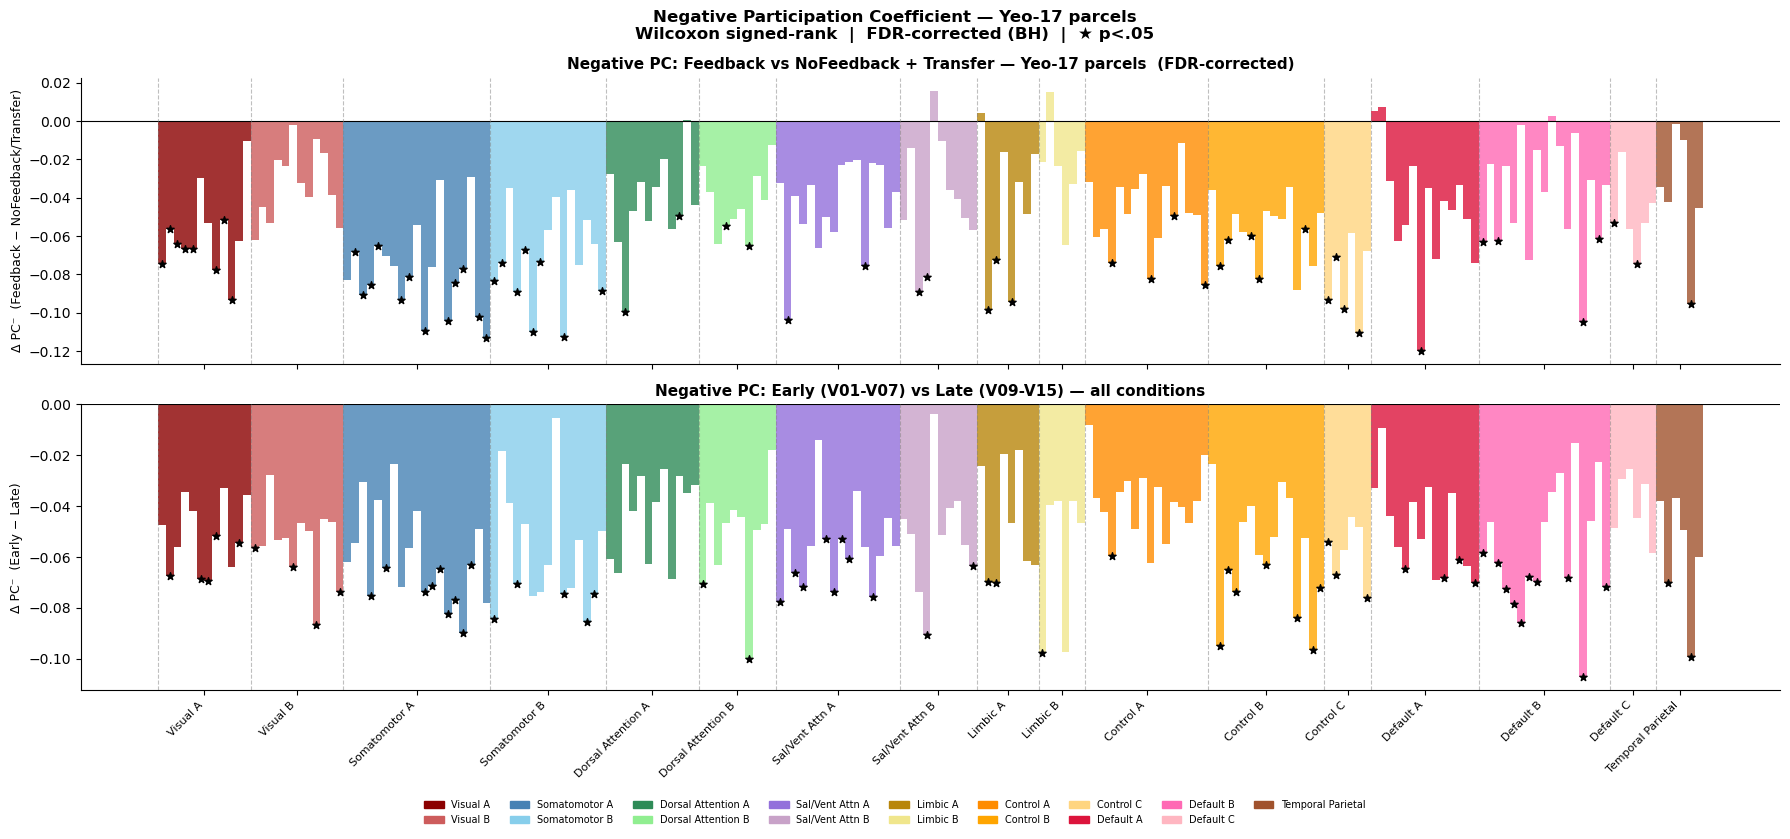


Condition contrast — sig parcels (FDR<0.05): 60
Epoch contrast    — sig parcels (FDR<0.05): 65


In [31]:
# ── Negative participation coefficient — Yeo-17 ────────────────────────────────
# Requires all_subjects_yeo17_metrics.csv to contain a 'pc_parcel_neg' column.
# Re-run the metrics pipeline with the updated metrics_yeo17.py if missing.

if "pc_parcel_neg" not in df_17.columns:
    raise RuntimeError(
        "'pc_parcel_neg' not found in all_subjects_yeo17_metrics.csv. "
        "Re-run the metrics pipeline with the updated metrics_yeo17.py."
    )

# ── Rebuild session dicts with pc_parcel_neg ──────────────────────────────────
all_data17_neg = {}
for (sid, sess_id, run_key), g in df_17.groupby(["subject", "session", "run"]):
    g = g.sort_values("parcel")
    subj = all_data17_neg.setdefault(sid, {"sessions": {}})
    all_data17_neg[sid]["sessions"].setdefault(sess_id, {})[run_key] = {
        "condition": g["condition"].iloc[0],
        "pc_parcel_neg": g["pc_parcel_neg"].values,
    }

# ── (subjects × sessions × parcels) matrices ─────────────────────────────────
def pc_neg_matrix17(condition):
    mat = np.full((len(sids17), len(SESSIONS), N_PARC17), np.nan)
    for si, sid in enumerate(sids17):
        for vi, sess in enumerate(SESSIONS):
            runs = all_data17_neg[sid]["sessions"].get(sess, {})
            vals = [
                rd["pc_parcel_neg"][cortical_mask17]
                for rd in runs.values()
                if rd["condition"] == condition
            ]
            if vals:
                mat[si, vi] = np.nanmean(vals, axis=0)
    return mat

pcn17_fb  = pc_neg_matrix17("Feedback")
pcn17_tr  = pc_neg_matrix17("Transfer")
pcn17_nfb = pc_neg_matrix17("NoFeedback")

pcn17_all  = np.nanmean(np.stack([pcn17_fb, pcn17_tr, pcn17_nfb], axis=0), axis=0)
pcn17_ctrl = np.nanmean(np.stack([pcn17_nfb, pcn17_tr], axis=0), axis=0)

# ── Per-subject means ─────────────────────────────────────────────────────────
mun17_fb    = np.nanmean(pcn17_fb,   axis=1)
mun17_ctrl  = np.nanmean(pcn17_ctrl, axis=1)
mun17_early = np.nanmean(pcn17_all[:, EARLY17, :], axis=1)
mun17_late  = np.nanmean(pcn17_all[:, LATE17,  :], axis=1)

# ── Wilcoxon + FDR per parcel — reuses parcel_wilcoxon17 from cell above ──────
eff_neg_cond,  pfdr_neg_cond  = parcel_wilcoxon17(mun17_fb,    mun17_ctrl)
eff_neg_epoch, pfdr_neg_epoch = parcel_wilcoxon17(mun17_early, mun17_late)

# ── Bar plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

for ax, effect, pvals_fdr, title, ylabel in [
    (axes[0],
     eff_neg_cond[sort_idx17],  pfdr_neg_cond[sort_idx17],
     "Negative PC: Feedback vs NoFeedback + Transfer — Yeo-17 parcels  (FDR-corrected)",
     "Δ PC⁻  (Feedback − NoFeedback/Transfer)"),
    (axes[1],
     eff_neg_epoch[sort_idx17], pfdr_neg_epoch[sort_idx17],
     "Negative PC: Early (V01-V07) vs Late (V09-V15) — all conditions",
     "Δ PC⁻  (Early − Late)"),
]:
    x = np.arange(N_PARC17)
    ax.bar(x, effect, color=colors17, width=1.0, linewidth=0, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8)

    for b in boundaries17:
        ax.axvline(b - 0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

    sig_x = np.where(pvals_fdr < 0.05)[0]
    ax.scatter(sig_x, effect[sig_x], marker="*", color="black", s=30, zorder=5)

    ax.set_xticks(net_centers17)
    ax.set_xticklabels(net_labels17, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch
legend_els = [
    Patch(color=YEO17_COLORS[net], label=YEO17_NAME_MAP[net])
    for net in YEO17_ORDER
]
fig.legend(handles=legend_els, loc="lower center",
           ncol=9, fontsize=7, frameon=False,
           bbox_to_anchor=(0.5, -0.05))

fig.suptitle(
    "Negative Participation Coefficient — Yeo-17 parcels\n"
    "Wilcoxon signed-rank  |  FDR-corrected (BH)  |  ★ p<.05",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pc_neg_yeo17_parcel_wilcoxon.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"\nCondition contrast — sig parcels (FDR<0.05): {(pfdr_neg_cond < 0.05).sum()}")
print(f"Epoch contrast    — sig parcels (FDR<0.05): {(pfdr_neg_epoch < 0.05).sum()}")

C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\61993596.py:33: RuntimeWarning: Mean of empty slice
  mat[si, vi] = np.nanmean(vals, axis=0)
C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\61993596.py:40: RuntimeWarning: Mean of empty slice
  pcn17_ctrl = np.nanmean(np.stack([pcn17_nfb, pcn17_tr], axis=0), axis=0)
C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\61993596.py:44: RuntimeWarning: Mean of empty slice
  mun17_ctrl = np.nanmean(pcn17_ctrl, axis=1)


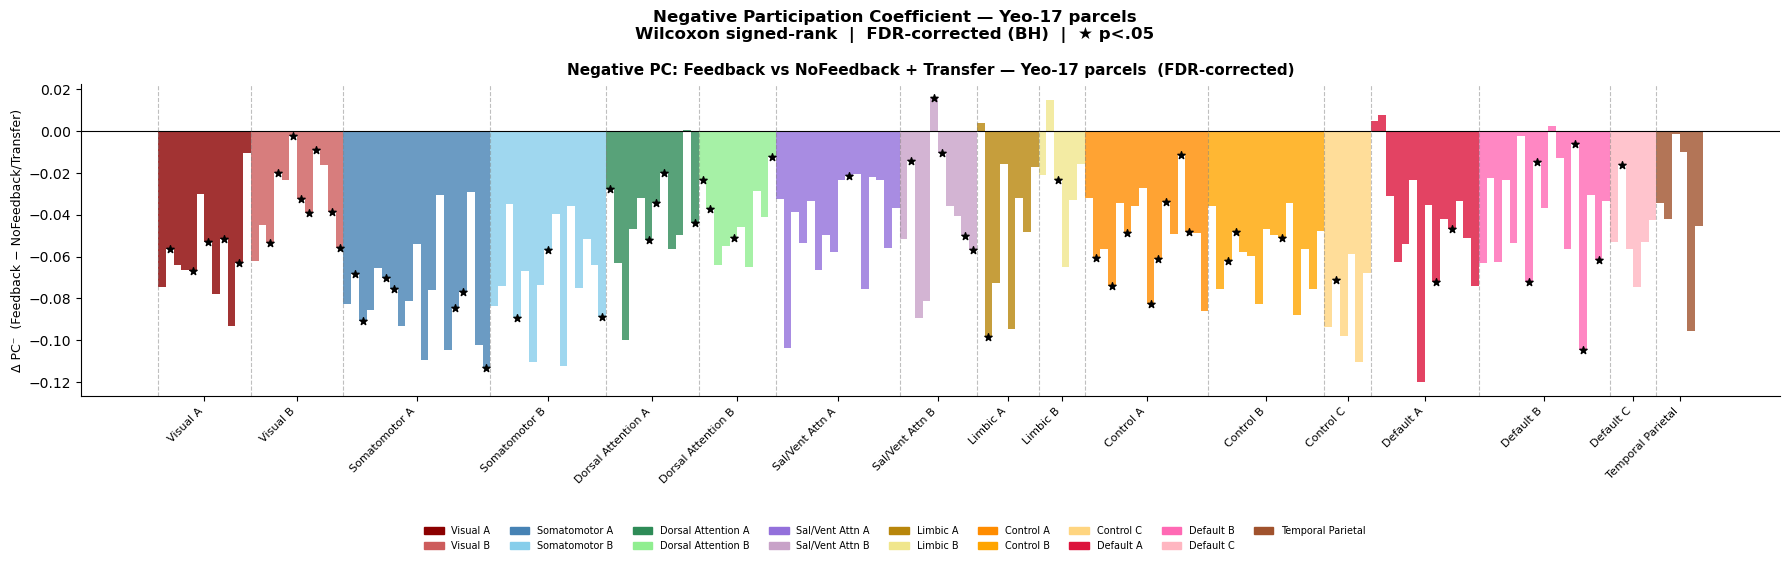

Condition contrast — sig parcels (FDR<0.05): 60


In [32]:
# ── Negative participation coefficient — Yeo-17 ────────────────────────────────
# Requires all_subjects_yeo17_metrics.csv to contain a 'pc_parcel_neg' column.
# Re-run the metrics pipeline with the updated metrics_yeo17.py if missing.

if "pc_parcel_neg" not in df_17.columns:
    raise RuntimeError(
        "'pc_parcel_neg' not found in all_subjects_yeo17_metrics.csv. "
        "Re-run the metrics pipeline with the updated metrics_yeo17.py."
    )

# ── Rebuild session dicts with pc_parcel_neg ──────────────────────────────────
all_data17_neg = {}
for (sid, sess_id, run_key), g in df_17.groupby(["subject", "session", "run"]):
    g = g.sort_values("parcel")
    subj = all_data17_neg.setdefault(sid, {"sessions": {}})
    all_data17_neg[sid]["sessions"].setdefault(sess_id, {})[run_key] = {
        "condition": g["condition"].iloc[0],
        "pc_parcel_neg": g["pc_parcel_neg"].values,
    }

# ── (subjects × sessions × parcels) matrices ─────────────────────────────────
def pc_neg_matrix17(condition):
    mat = np.full((len(sids17), len(SESSIONS), N_PARC17), np.nan)
    for si, sid in enumerate(sids17):
        for vi, sess in enumerate(SESSIONS):
            runs = all_data17_neg[sid]["sessions"].get(sess, {})
            vals = [
                rd["pc_parcel_neg"][cortical_mask17]
                for rd in runs.values()
                if rd["condition"] == condition
            ]
            if vals:
                mat[si, vi] = np.nanmean(vals, axis=0)
    return mat

pcn17_fb  = pc_neg_matrix17("Feedback")
pcn17_tr  = pc_neg_matrix17("Transfer")
pcn17_nfb = pc_neg_matrix17("NoFeedback")

pcn17_ctrl = np.nanmean(np.stack([pcn17_nfb, pcn17_tr], axis=0), axis=0)

# ── Per-subject means ─────────────────────────────────────────────────────────
mun17_fb   = np.nanmean(pcn17_fb,   axis=1)
mun17_ctrl = np.nanmean(pcn17_ctrl, axis=1)

# ── Wilcoxon + FDR per parcel ─────────────────────────────────────────────────
eff_neg_cond, pfdr_neg_cond = parcel_wilcoxon17(mun17_fb, mun17_ctrl)

# ── Bar plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))

x = np.arange(N_PARC17)
ax.bar(x, eff_neg_cond[sort_idx17], color=colors17, width=1.0, linewidth=0, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)

for b in boundaries17:
    ax.axvline(b - 0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

sig_x = np.where(pfdr_neg_cond < 0.05)[0]
ax.scatter(sig_x, eff_neg_cond[sort_idx17][sig_x], marker="*", color="black", s=30, zorder=5)

ax.set_xticks(net_centers17)
ax.set_xticklabels(net_labels17, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Δ PC⁻  (Feedback − NoFeedback/Transfer)", fontsize=9)
ax.set_title(
    "Negative PC: Feedback vs NoFeedback + Transfer — Yeo-17 parcels  (FDR-corrected)",
    fontsize=11, fontweight="bold"
)
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch
legend_els = [
    Patch(color=YEO17_COLORS[net], label=YEO17_NAME_MAP[net])
    for net in YEO17_ORDER
]
fig.legend(handles=legend_els, loc="lower center",
           ncol=9, fontsize=7, frameon=False,
           bbox_to_anchor=(0.5, -0.12))

fig.suptitle(
    "Negative Participation Coefficient — Yeo-17 parcels\n"
    "Wilcoxon signed-rank  |  FDR-corrected (BH)  |  ★ p<.05",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pc_neg_yeo17_parcel_wilcoxon.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"Condition contrast — sig parcels (FDR<0.05): {(pfdr_neg_cond < 0.05).sum()}")

C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\1587202191.py:13: RuntimeWarning: Mean of empty slice
  mat[si, vi] = np.nanmean(vals, axis=0)
C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\1587202191.py:20: RuntimeWarning: Mean of empty slice
  pcn_ctrl = np.nanmean(np.stack([pcn_nofb, pcn_tr], axis=0), axis=0)
C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\1587202191.py:23: RuntimeWarning: Mean of empty slice
  mun_ctrl = np.nanmean(pcn_ctrl, axis=1)


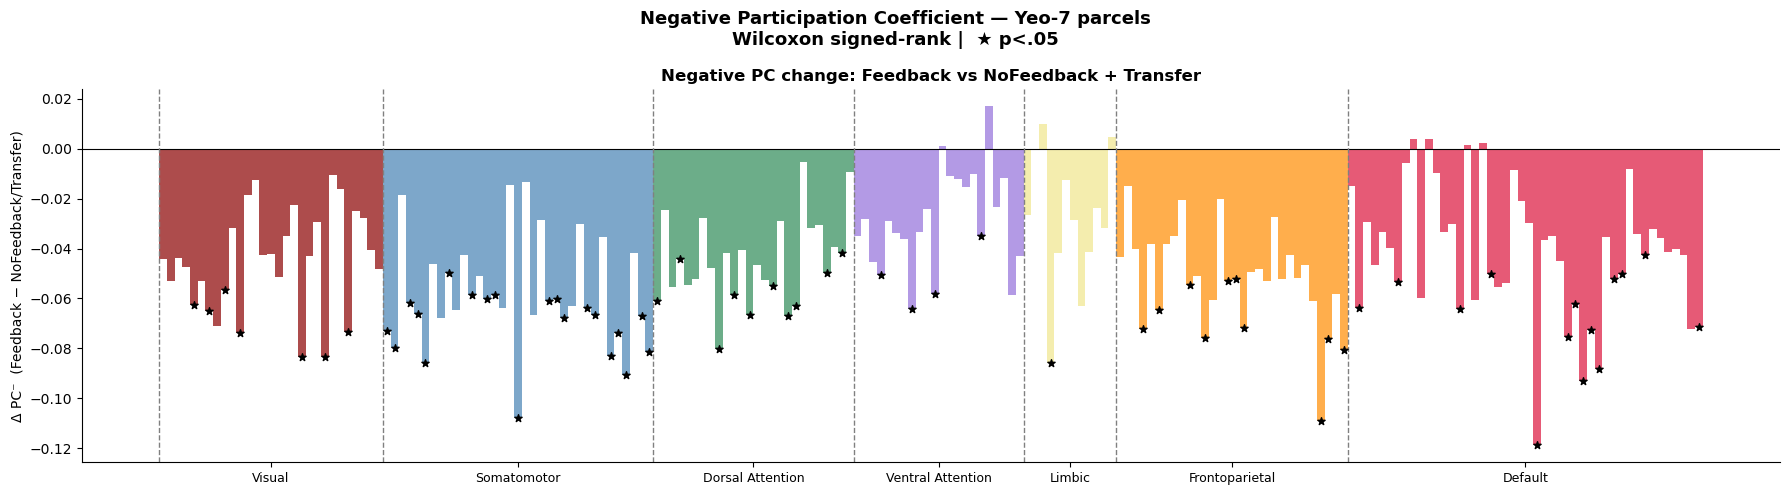

Condition contrast — sig parcels (FDR<0.05): 66


In [33]:
# ── Feedback vs (NoFeedback + Transfer), per parcel — Negative PC, Yeo-7 ──────
def pc_neg_session_matrix(all_data, condition):
    mat = np.full((len(sids), len(SESSIONS), N_PARC), np.nan)
    for si, sid in enumerate(sids):
        for vi, sess in enumerate(SESSIONS):
            runs = all_data[sid]["sessions"].get(sess, {})
            vals = [
                rd["pc_parcel_neg"][cortical_mask]
                for rd in runs.values()
                if rd["condition"] == condition
            ]
            if vals:
                mat[si, vi] = np.nanmean(vals, axis=0)
    return mat, None

pcn_fb,   _ = pc_neg_session_matrix(all_data, condition="Feedback")
pcn_nofb, _ = pc_neg_session_matrix(all_data, condition="NoFeedback")
pcn_tr,   _ = pc_neg_session_matrix(all_data, condition="Transfer")

pcn_ctrl = np.nanmean(np.stack([pcn_nofb, pcn_tr], axis=0), axis=0)

mun_fb   = np.nanmean(pcn_fb,   axis=1)
mun_ctrl = np.nanmean(pcn_ctrl, axis=1)

diff   = mun_fb - mun_ctrl
effect = np.nanmean(diff, axis=0)

pvals = np.array([
    wilcoxon(
        diff[~np.isnan(diff[:, p]), p],
        alternative="two-sided"
    ).pvalue
    if (np.sum(~np.isnan(diff[:, p])) >= 5
        and not np.all(diff[~np.isnan(diff[:, p]), p] == 0))
    else np.nan
    for p in range(N_PARC)
])

valid = ~np.isnan(pvals)
_, pvals_fdr, _, _ = multipletests(pvals[valid], method="fdr_bh")
pvals_corr = np.full(N_PARC, np.nan)
pvals_corr[valid] = pvals_fdr
sig = pvals_corr < 0.05

effect_sorted = effect[sort_idx_net]
sig_sorted    = sig[sort_idx_net]
colors_s      = [YEO_COLORS[y - 1] for y in yeo_cx[sort_idx_net]]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(range(N_PARC), effect_sorted, color=colors_s, width=1.0, linewidth=0, alpha=0.7)
sig_x = np.where(sig_sorted)[0]
ax.scatter(sig_x, effect_sorted[sig_sorted], marker="*", color="black", s=30, zorder=5)
ax.axhline(0, color="black", linewidth=0.8)
for b in boundaries:
    ax.axvline(b - 0.5, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(net_centers)
ax.set_xticklabels(YEO_NAMES, fontsize=9)
ax.set_ylabel("Δ PC⁻  (Feedback − NoFeedback/Transfer)")
ax.set_title("Negative PC change: Feedback vs NoFeedback + Transfer", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Negative Participation Coefficient — Yeo-7 parcels\n"
    "Wilcoxon signed-rank |  ★ p<.05",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pc_neg_yeo7_parcel_wilcoxon_condition.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"Condition contrast — sig parcels (FDR<0.05): {(pvals_corr < 0.05).sum()}")

In [34]:
from collections import Counter

# ── Negative PC — significant parcel summary ─────────────────────────────────

# Yeo-7  (pvals_corr from the parcel Wilcoxon cell above)
sig7_neg = pvals_corr < 0.05
counts7_neg = Counter(yeo_cx[sig7_neg])
print(f"Condition (Feedback vs ctrl) — Negative PC Yeo-7 — sig parcels: {sig7_neg.sum()} / {N_PARC}")
for net_id, n in sorted(counts7_neg.items(), key=lambda x: -x[1]):
    print(f"  {YEO_NAMES[net_id - 1]}: {n}")

# Yeo-17  (pfdr_neg_cond from the Yeo-17 negative PC cell)
sig17_neg = pfdr_neg_cond < 0.05
counts17_neg = Counter(net17_labels[sig17_neg])
print(f"\nCondition (Feedback vs ctrl) — Negative PC Yeo-17 — sig parcels: {sig17_neg.sum()} / {N_PARC17}")
for net, n in sorted(counts17_neg.items(), key=lambda x: -x[1]):
    print(f"  {YEO17_NAME_MAP[net]}: {n}")


Condition (Feedback vs ctrl) — Negative PC Yeo-7 — sig parcels: 66 / 200
  Somatomotor: 20
  Default: 14
  Dorsal Attention: 10
  Frontoparietal: 10
  Visual: 7
  Ventral Attention: 4
  Limbic: 1

Condition (Feedback vs ctrl) — Negative PC Yeo-17 — sig parcels: 60 / 200
  Somatomotor A: 12
  Visual A: 8
  Somatomotor B: 8
  Control B: 5
  Control C: 4
  Control A: 4
  Default B: 4
  Limbic A: 3
  Dorsal Attention A: 2
  Dorsal Attention B: 2
  Sal/Vent Attn A: 2
  Sal/Vent Attn B: 2
  Default C: 2
  Default A: 1
  Temporal Parietal: 1


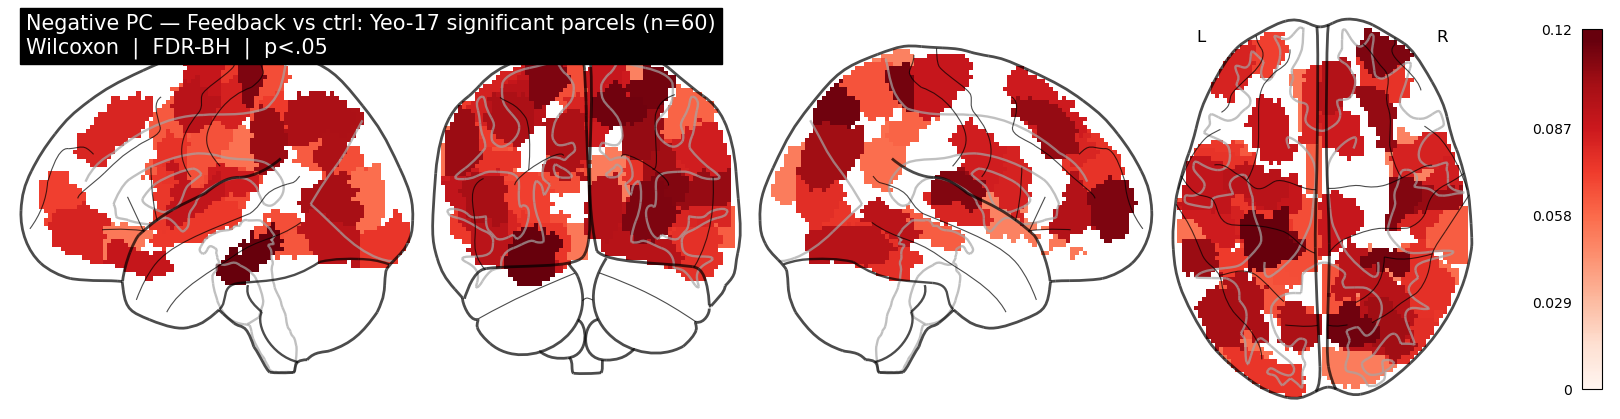

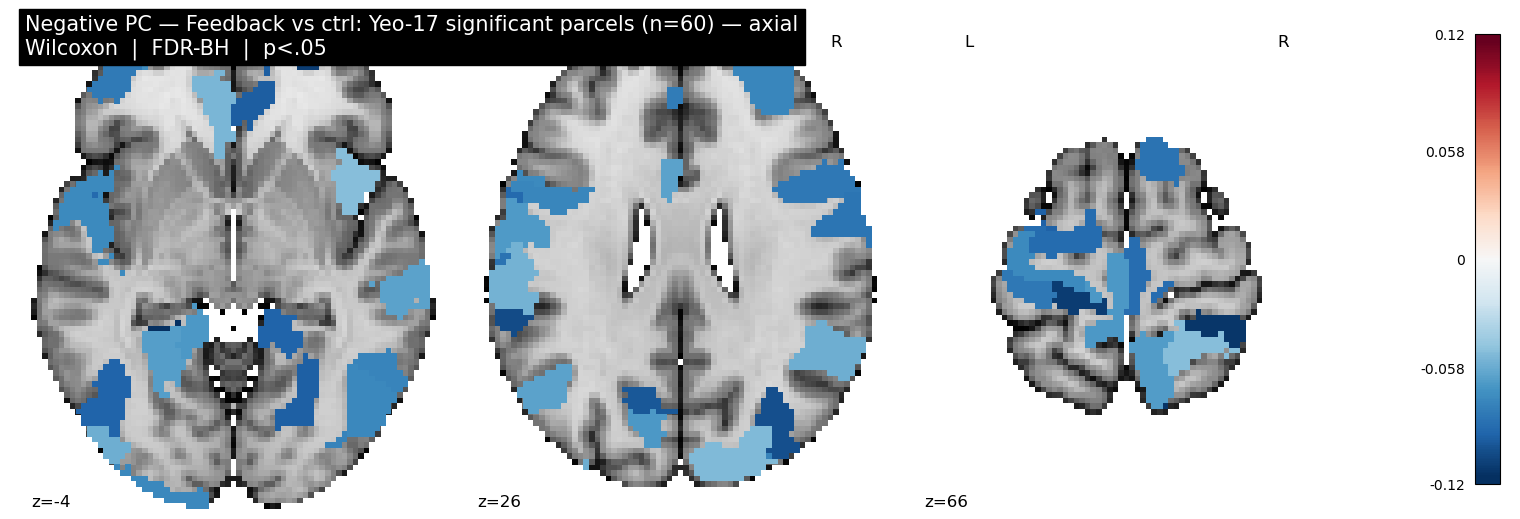

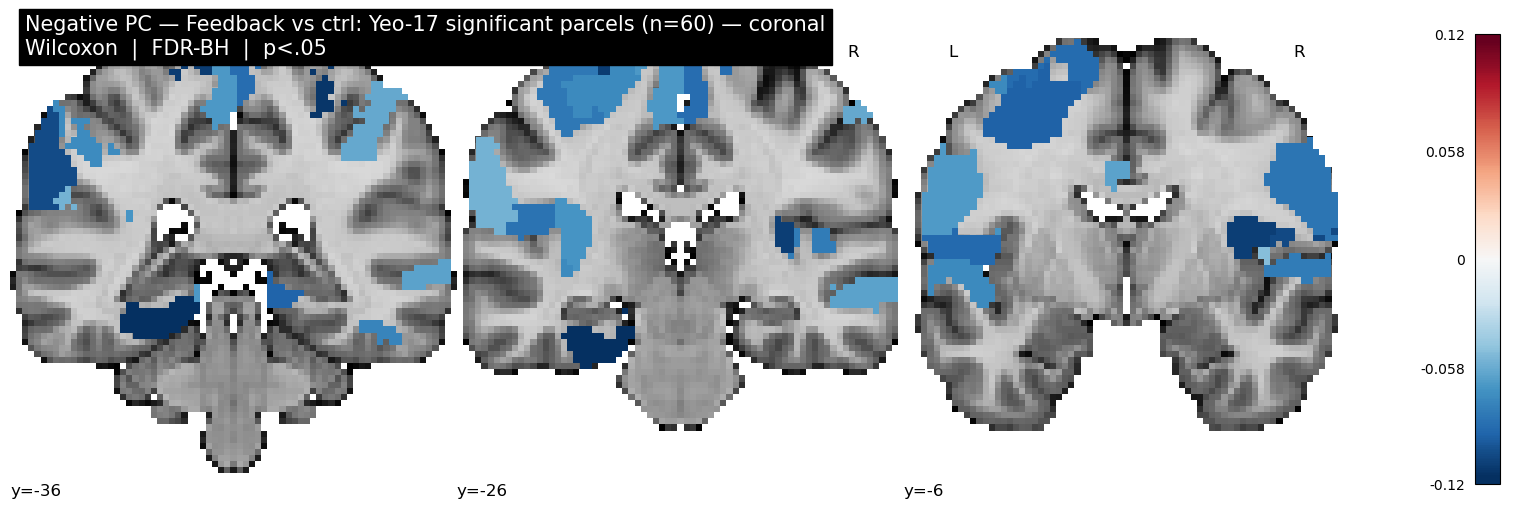

In [35]:
brain_parcel_plot_patches(
    sig17_neg, eff_neg_cond,
    title=f"Negative PC — Feedback vs ctrl: Yeo-17 significant parcels (n={sig17_neg.sum()})",
    cbar_label="Δ PC⁻ (Feedback − ctrl)",
    out_stem="pc_neg_cond_yeo17",
)


Auditory significant parcels: 3


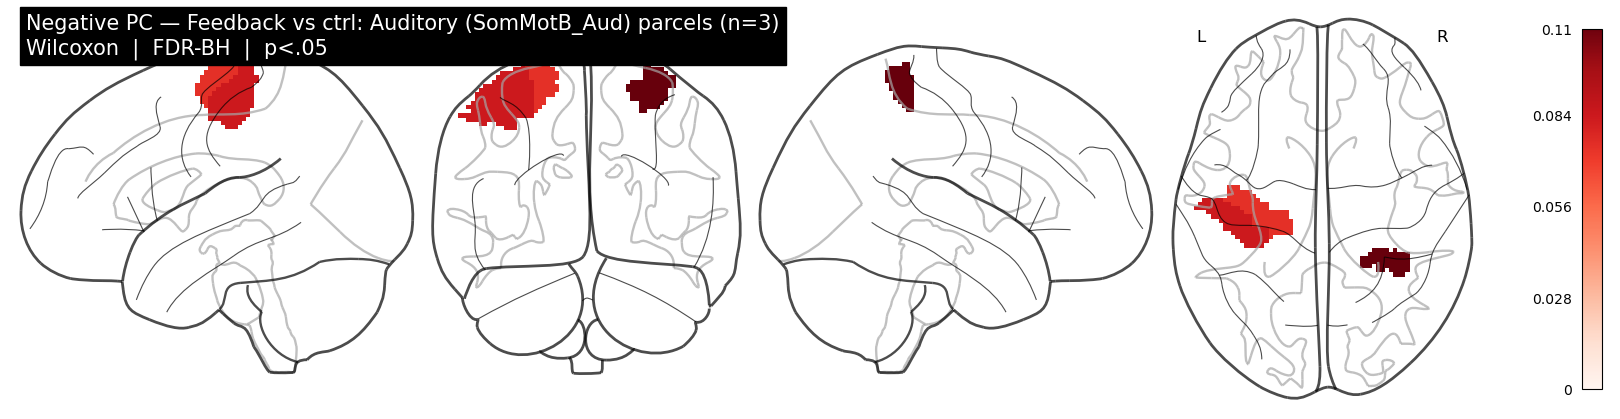

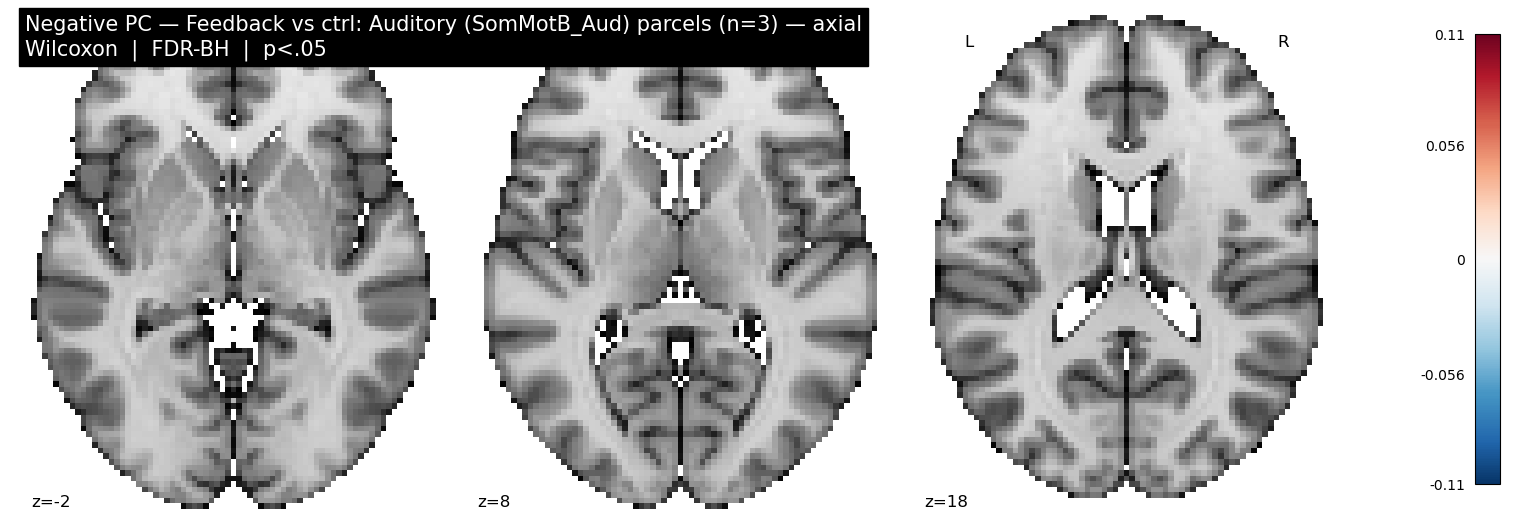

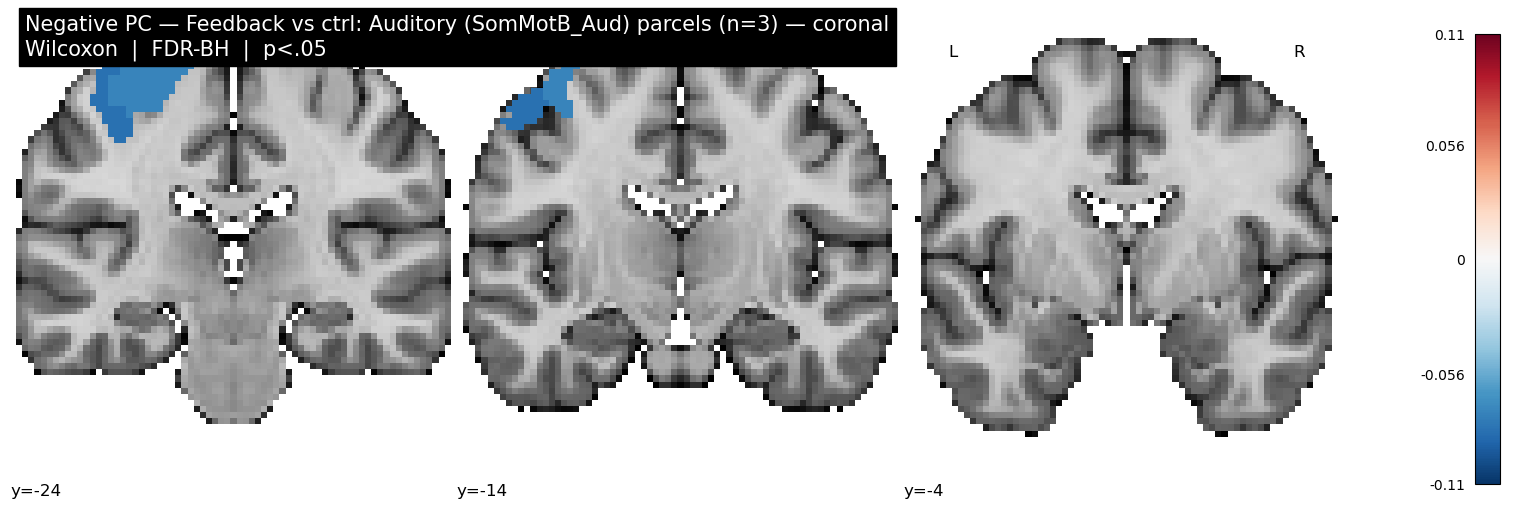

In [36]:
aud_mask = np.array([
    "Aud" in (label17_map.get(cortical_parcel_nums[p] + 1, "") or "")
    for p in range(N_PARC17)
])

sig17_neg_aud = sig17_neg & aud_mask

print(f"Auditory significant parcels: {sig17_neg_aud.sum()}")

brain_parcel_plot_patches(
    sig17_neg_aud, eff_neg_cond,
    title=f"Negative PC — Feedback vs ctrl: Auditory (SomMotB_Aud) parcels (n={sig17_neg_aud.sum()})",
    cbar_label="Δ PC⁻ (Feedback − ctrl)",
    out_stem="pc_neg_cond_aud",
)


Somatomotor significant parcels: 20


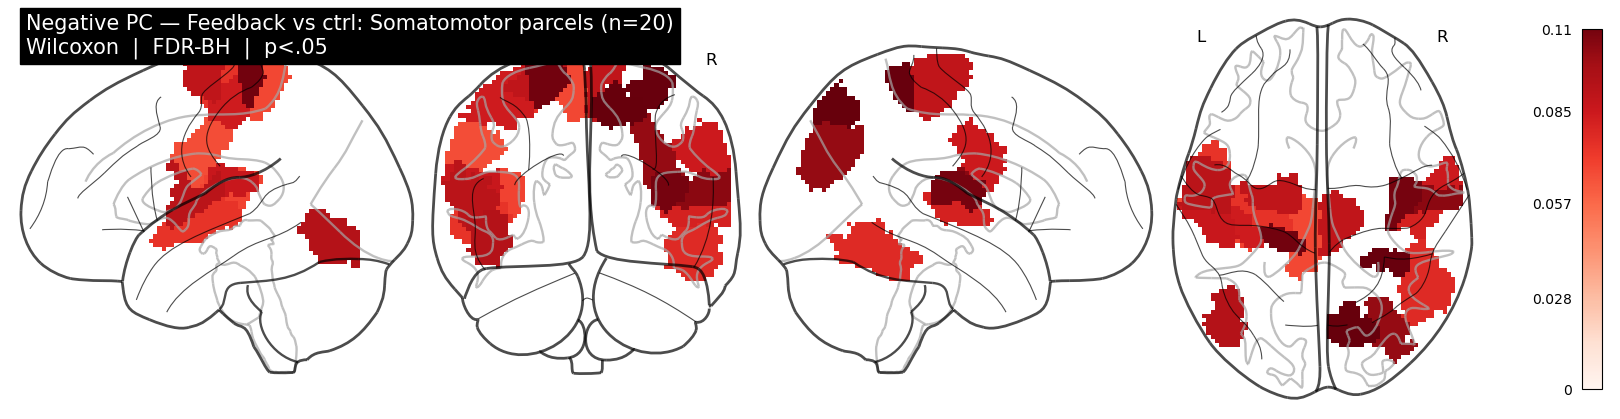

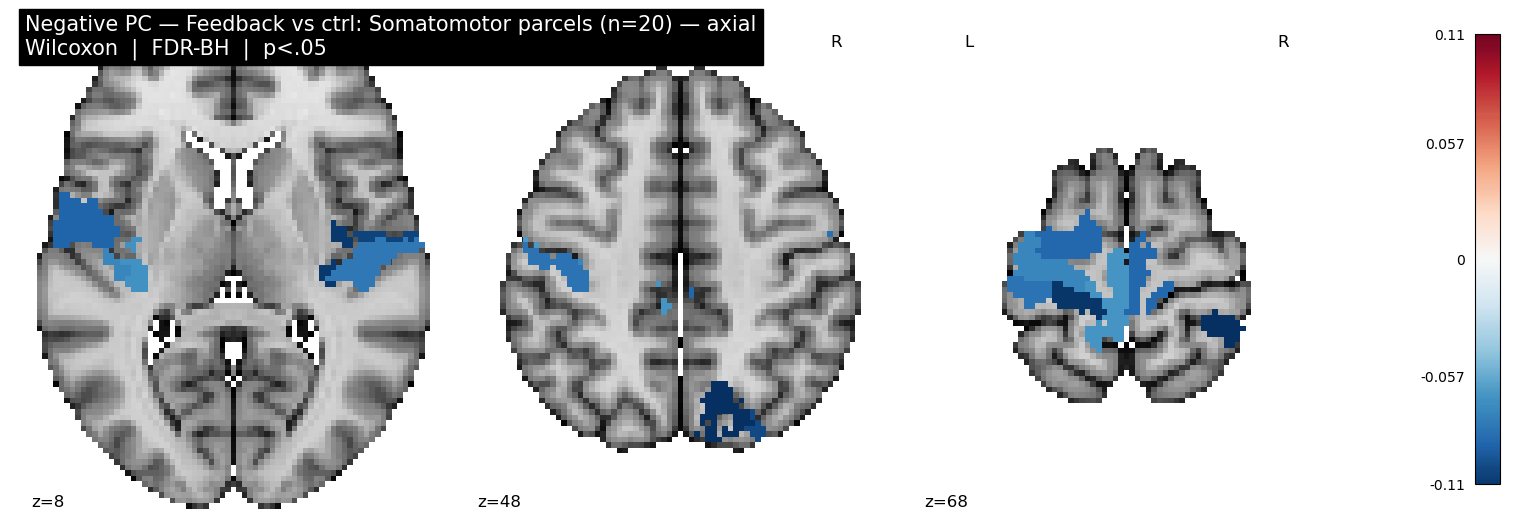

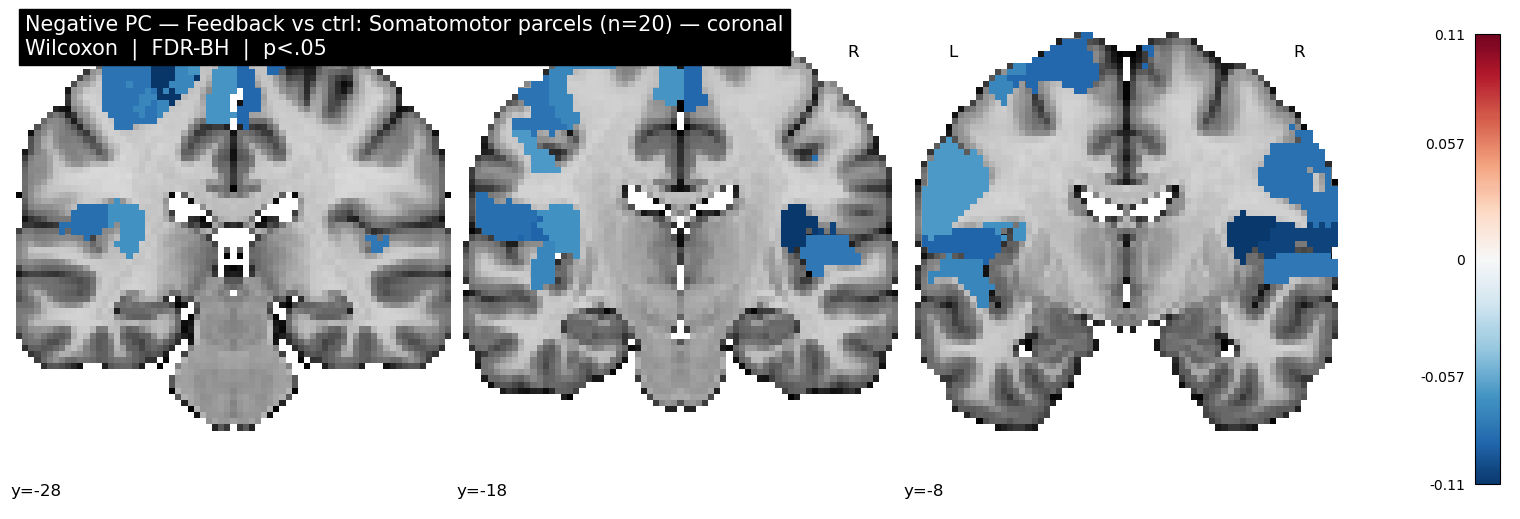

In [37]:
sombot_mask = np.isin(net17_labels, ["SomMotA", "SomMotB"])

sig17_neg_sombot = sig17_neg & sombot_mask

print(f"Somatomotor significant parcels: {sig17_neg_sombot.sum()}")

brain_parcel_plot_patches(
    sig17_neg_sombot, eff_neg_cond,
    title=f"Negative PC — Feedback vs ctrl: Somatomotor parcels (n={sig17_neg_sombot.sum()})",
    cbar_label="Δ PC⁻ (Feedback − ctrl)",
    out_stem="pc_neg_cond_sombot",
)


Control significant parcels: 13


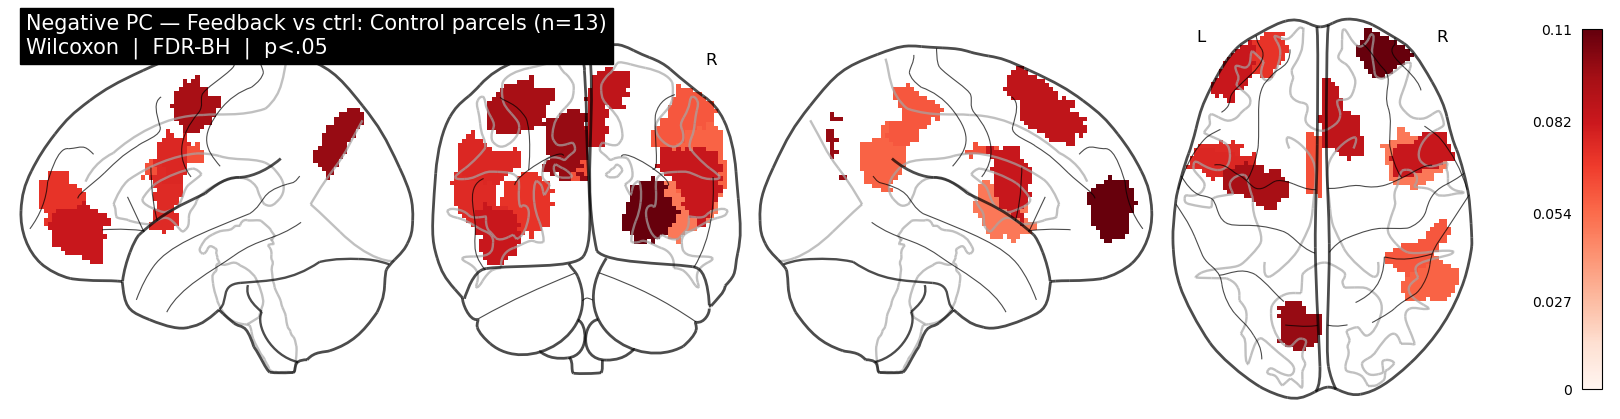

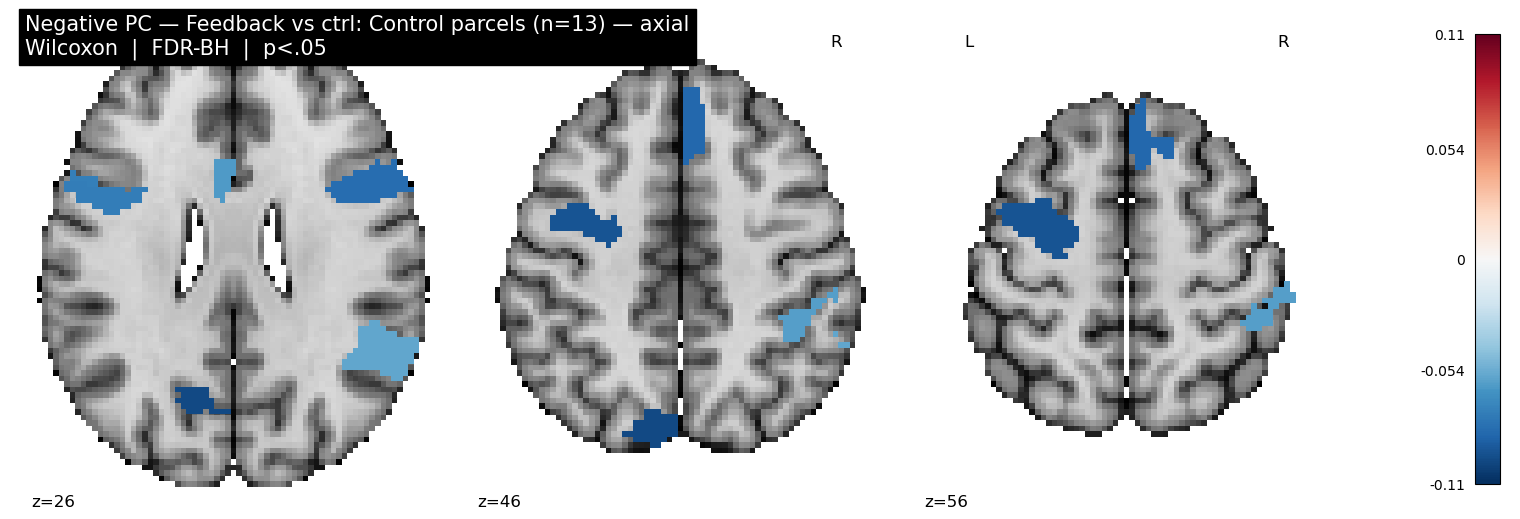

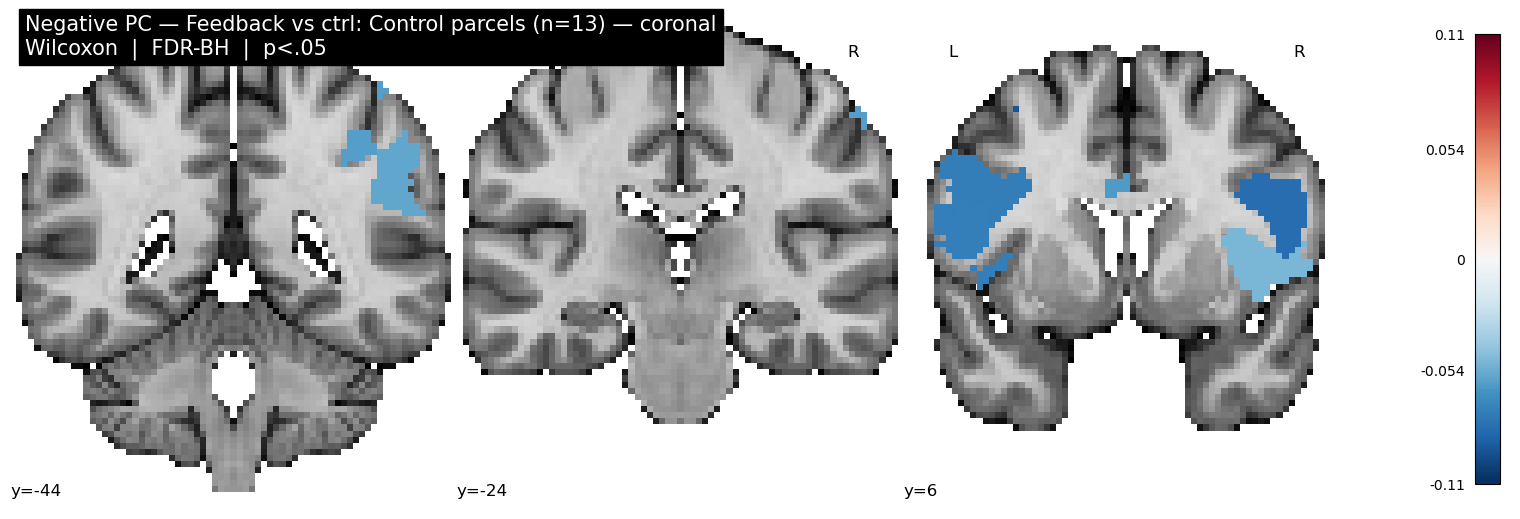

In [38]:
cont_mask = np.isin(net17_labels, ["ContA", "ContB", "ContC"])

sig17_neg_cont = sig17_neg & cont_mask

print(f"Control significant parcels: {sig17_neg_cont.sum()}")

brain_parcel_plot_patches(
    sig17_neg_cont, eff_neg_cond,
    title=f"Negative PC — Feedback vs ctrl: Control parcels (n={sig17_neg_cont.sum()})",
    cbar_label="Δ PC⁻ (Feedback − ctrl)",
    out_stem="pc_neg_cond_cont",
)


Visual significant parcels: 8


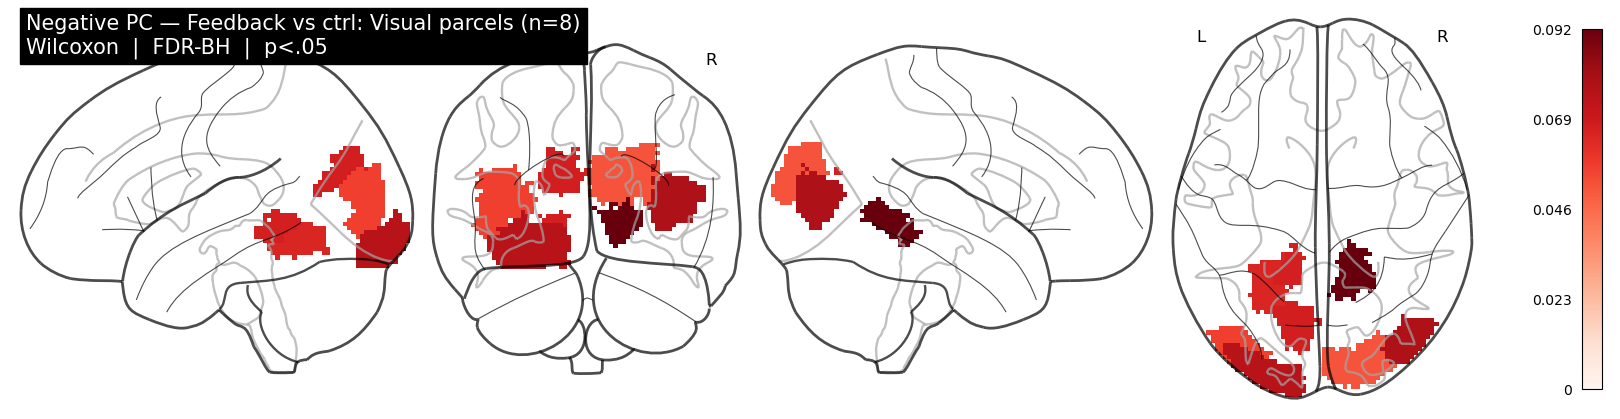

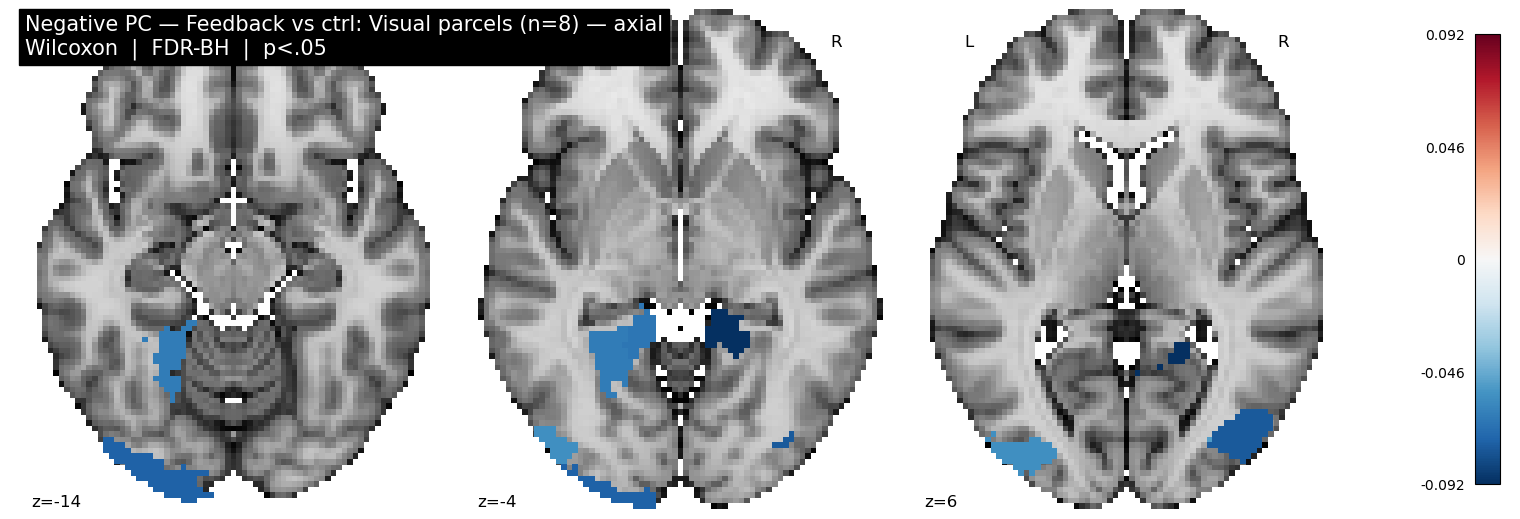

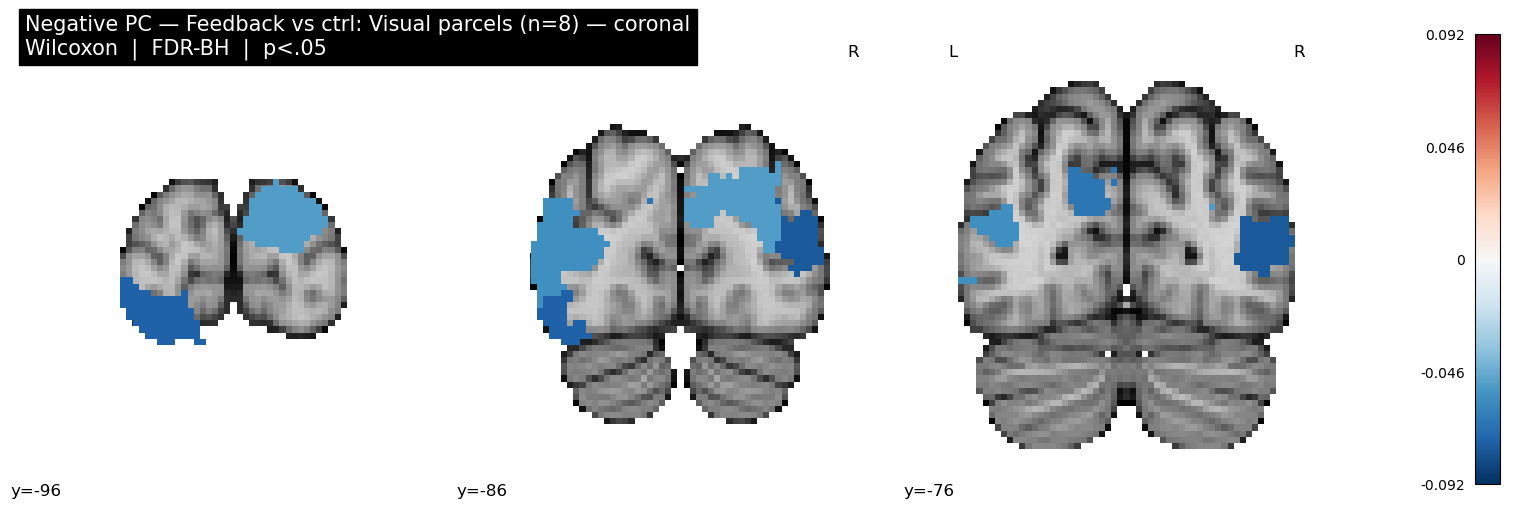

In [39]:
vis_mask = np.isin(net17_labels, ["VisCent", "VisPeri"])

sig17_neg_vis = sig17_neg & vis_mask

print(f"Visual significant parcels: {sig17_neg_vis.sum()}")

brain_parcel_plot_patches(
    sig17_neg_vis, eff_neg_cond,
    title=f"Negative PC — Feedback vs ctrl: Visual parcels (n={sig17_neg_vis.sum()})",
    cbar_label="Δ PC⁻ (Feedback − ctrl)",
    out_stem="pc_neg_cond_vis",
)


In [40]:
from collections import Counter

# Load Schaefer 17-network atlas to get sub-labels (Aud/S2/Cent within SomMotB)
matched = pd.read_csv(os.path.join(UTILS_DIR, "matched_labels_exact.csv"))
label17_map = dict(zip(matched["ROI Label"], matched["label_df2"]))
cortical_parcel_nums = parcel_net17.loc[cortical_mask17, "parcel"].values  # original 1-indexed parcel IDs

for label, pfdr in [("Condition (Feedback vs ctrl)", pfdr_neg_cond),
                    ("Epoch (Early vs Late)",        pfdr_neg_epoch)]:
    sig17 = pfdr < 0.05
    counts17 = Counter(net17_labels[sig17])
    print(f"\n{label} — significant parcels: {sig17.sum()} / {N_PARC17}")
    for net, n in sorted(counts17.items(), key=lambda x: -x[1]):
        print(f"  {YEO17_NAME_MAP[net]}: {n}")

    somemot_sig = sig17 & np.isin(net17_labels, ["SomMotA", "SomMotB"])
    if somemot_sig.any():
        print("  SomMot auditory check:")
        for p in np.where(somemot_sig)[0]:
            roi = label17_map.get(cortical_parcel_nums[p] + 1, "Unknown")
            tag = "← AUDITORY" if "_Aud_" in roi else "← S2" if "_S2_" in roi else "← Cent" if "_Cent_" in roi else ""
            print(f"    {roi}  {tag}")
    else:
        print("  No significant SomMot parcels.")



Condition (Feedback vs ctrl) — significant parcels: 60 / 200
  Somatomotor A: 12
  Visual A: 8
  Somatomotor B: 8
  Control B: 5
  Control C: 4
  Control A: 4
  Default B: 4
  Limbic A: 3
  Dorsal Attention A: 2
  Dorsal Attention B: 2
  Sal/Vent Attn A: 2
  Sal/Vent Attn B: 2
  Default C: 2
  Default A: 1
  Temporal Parietal: 1
  SomMot auditory check:
    17Networks_LH_SomMotB_Aud_1  ← AUDITORY
    17Networks_LH_SomMotB_Aud_2  ← AUDITORY
    17Networks_LH_SomMotB_S2_2  ← S2
    17Networks_LH_SomMotB_S2_3  ← S2
    17Networks_LH_SomMotB_Cent_1  ← Cent
    17Networks_LH_SomMotB_Cent_2  ← Cent
    17Networks_LH_SomMotA_2  
    17Networks_LH_SomMotA_3  
    17Networks_LH_SomMotA_4  
    17Networks_LH_SomMotA_5  
    17Networks_LH_SomMotA_8  
    17Networks_RH_SomMotB_Aud_2  ← AUDITORY
    17Networks_RH_SomMotB_Cent_1  ← Cent
    17Networks_RH_SomMotA_1  
    17Networks_RH_SomMotA_3  
    17Networks_RH_SomMotA_6  
    17Networks_RH_SomMotA_7  
    17Networks_RH_SomMotA_8  
    17Networks

In [41]:
# ── Positive vs Negative PC: same or different parcels? ───────────────────────
# Compares which parcels are significant (FDR<0.05)
# for positive PC vs negative PC, for both contrasts.

SIG_POS_COND  = (pfdr_cond      < 0.05)
SIG_NEG_COND  = (pfdr_neg_cond  < 0.05)
SIG_POS_EPOCH = (pfdr_epoch     < 0.05)
SIG_NEG_EPOCH = (pfdr_neg_epoch < 0.05)

for label, sig_pos, sig_neg, eff_pos, eff_neg in [
    ("Feedback vs ctrl",          SIG_POS_COND,  SIG_NEG_COND,  eff_cond,  eff_neg_cond),
    ("Early vs Late",             SIG_POS_EPOCH, SIG_NEG_EPOCH, eff_epoch, eff_neg_epoch),
]:
    only_pos = sig_pos & ~sig_neg
    only_neg = sig_neg & ~sig_pos
    both_sig = sig_pos &  sig_neg

    print(f"\n── {label} ──────────────────────────────────────")
    print(f"  Changing positive PC only : {only_pos.sum():3d} parcels")
    print(f"  Changing negative PC only : {only_neg.sum():3d} parcels")
    print(f"  Changing in BOTH          : {both_sig.sum():3d} parcels")

    if both_sig.any():
        nets = net17_labels[both_sig]
        from collections import Counter
        net_counts = Counter(nets)
        print("    Networks (shared parcels):", dict(sorted(net_counts.items(),
              key=lambda x: -x[1])))
        



── Feedback vs ctrl ──────────────────────────────────────
  Changing positive PC only :  19 parcels
  Changing negative PC only :  38 parcels
  Changing in BOTH          :  22 parcels
    Networks (shared parcels): {'SomMotA': 8, 'SomMotB': 5, 'ContA': 2, 'DefaultC': 1, 'DefaultA': 1, 'DorsAttnB': 1, 'SalVentAttnA': 1, 'ContB': 1, 'ContC': 1, 'TempPar': 1}

── Early vs Late ──────────────────────────────────────
  Changing positive PC only :  29 parcels
  Changing negative PC only :  34 parcels
  Changing in BOTH          :  31 parcels
    Networks (shared parcels): {'SalVentAttnA': 6, 'DefaultB': 6, 'SomMotA': 5, 'SomMotB': 4, 'DefaultA': 4, 'ContB': 2, 'VisCent': 1, 'DorsAttnB': 1, 'TempPar': 1, 'ContC': 1}


In [42]:
matched = pd.read_csv(os.path.join(UTILS_DIR, "matched_labels_exact.csv"))
# cortical_parcel_nums[p] + 1 → Yeo-7 ROI Label → label_df2 gives the Yeo-17 sub-name
label17_map = dict(zip(matched["ROI Label"], matched["label_df2"]))

# Quick verification — should match net17_labels
for p in range(5):
    name17 = label17_map.get(cortical_parcel_nums[p] + 1, "Unknown")
    print(f"  parcel {cortical_parcel_nums[p]}  net17_labels={net17_labels[p]:<12s}  matched={name17}")


  parcel 0  net17_labels=VisPeri       matched=17Networks_LH_VisPeri_ExStrInf_1
  parcel 1  net17_labels=VisCent       matched=17Networks_LH_VisCent_ExStr_1
  parcel 2  net17_labels=DorsAttnA     matched=17Networks_LH_DorsAttnA_TempOcc_2
  parcel 3  net17_labels=VisPeri       matched=17Networks_LH_VisPeri_ExStrInf_2
  parcel 4  net17_labels=VisCent       matched=17Networks_LH_VisCent_ExStr_2


In [43]:
# ── Robustness check: exclude first and last two sessions ─────────────────────
# Tests whether the Feedback vs ctrl condition effect holds in sessions 3–13,
# removing boundary sessions (V01, V02, V03) that may reflect novelty/fatigue.

EXCLUDE = {"V01", "V02", "V03"}
MIDDLE_IDX = [i for i, s in enumerate(SESSIONS) if s not in EXCLUDE]
print(f"Sessions kept: {[SESSIONS[i] for i in MIDDLE_IDX]}")

# Recompute per-subject means over middle sessions only
mu17_fb_mid   = np.nanmean(pc17_fb[:,   MIDDLE_IDX, :], axis=1)
mu17_ctrl_mid = np.nanmean(pc17_ctrl[:, MIDDLE_IDX, :], axis=1)

eff_cond_mid, pfdr_cond_mid = parcel_wilcoxon17(mu17_fb_mid, mu17_ctrl_mid)

sig_orig = pfdr_cond < 0.05
sig_mid  = pfdr_cond_mid < 0.05

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nOriginal (all 15 sessions):   {sig_orig.sum()} significant parcels")
print(f"Robustness (sessions 3–13):   {sig_mid.sum()} significant parcels")
print(f"Overlap (sig in both):        {(sig_orig & sig_mid).sum()} parcels")

counts_mid = Counter(net17_labels[sig_mid])
print("\nNetwork breakdown (middle sessions):")
for net, n in sorted(counts_mid.items(), key=lambda x: -x[1]):
    print(f"  {YEO17_NAME_MAP[net]}: {n}")

# ── Auditory check ────────────────────────────────────────────────────────────
somemot_mid = sig_mid & np.isin(net17_labels, ["SomMotA", "SomMotB"])
print(f"\nSomMot significant: {somemot_mid.sum()}")
for p in np.where(somemot_mid)[0]:
    roi = label17_map.get(cortical_parcel_nums[p] + 1, "Unknown")
    tag = "← AUDITORY" if "_Aud_" in roi else "← S2" if "_S2_" in roi else "← Cent" if "_Cent_" in roi else ""
    print(f"  {roi}  {tag}")


Sessions kept: ['V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15']

Original (all 15 sessions):   41 significant parcels
Robustness (sessions 3–13):   12 significant parcels
Overlap (sig in both):        12 parcels

Network breakdown (middle sessions):
  Somatomotor A: 4
  Somatomotor B: 2
  Control B: 2
  Visual A: 1
  Dorsal Attention B: 1
  Control C: 1
  Temporal Parietal: 1

SomMot significant: 6
  17Networks_LH_SomMotB_S2_3  ← S2
  17Networks_LH_SomMotA_1  
  17Networks_LH_SomMotA_7  
  17Networks_RH_SomMotB_S2_2  ← S2
  17Networks_RH_SomMotA_6  
  17Networks_RH_SomMotA_10  


In [44]:
# Test removing only first two vs only last two
for label, exclude in [
    ("Remove V01–V02 only",  {"V01", "V02"}),
    ("Remove V14–V15 only",  {"V14", "V15"}),
    ("Remove all four",      {"V01", "V02", "V14", "V15"}),
]:
    idx = [i for i, s in enumerate(SESSIONS) if s not in exclude]
    mu_fb_r   = np.nanmean(pc17_fb[:,   idx, :], axis=1)
    mu_ctrl_r = np.nanmean(pc17_ctrl[:, idx, :], axis=1)
    _, pfdr_r = parcel_wilcoxon17(mu_fb_r, mu_ctrl_r)
    print(f"{label}: {(pfdr_r < 0.05).sum()} significant parcels")


Remove V01–V02 only: 16 significant parcels
Remove V14–V15 only: 20 significant parcels
Remove all four: 11 significant parcels


C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\2670951580.py:10: RuntimeWarning: Mean of empty slice
  np.nanmean(pc17_ctrl[:, :, sig_parcels], axis=2)
C:\Users\tesni\AppData\Local\Temp\ipykernel_24672\2670951580.py:14: RuntimeWarning: Mean of empty slice
  mean_diff = np.nanmean(diff_by_sess, axis=0)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


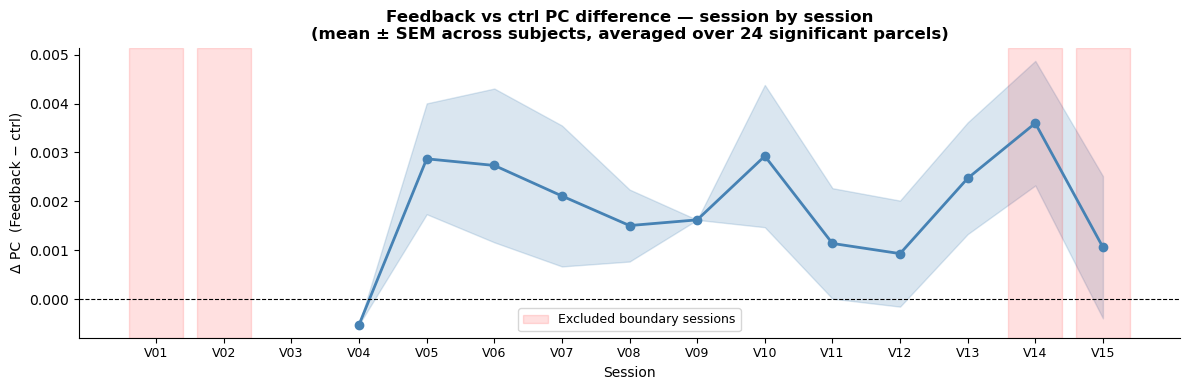

In [45]:
# ── Session-by-session Feedback vs ctrl difference ────────────────────────────
# Average over the 24 FDR-significant parcels to show how the condition effect
# varies across sessions (reveals whether boundary sessions drive the effect).

sig_parcels = np.where(pfdr_cond < 0.05)[0]

# (n_subj × n_sess): mean PC diff over significant parcels
diff_by_sess = (
    np.nanmean(pc17_fb[:,   :, sig_parcels], axis=2) -
    np.nanmean(pc17_ctrl[:, :, sig_parcels], axis=2)
)

n_valid   = np.sum(~np.isnan(diff_by_sess), axis=0)
mean_diff = np.nanmean(diff_by_sess, axis=0)
sem_diff  = np.nanstd(diff_by_sess,  axis=0) / np.sqrt(n_valid)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(SESSIONS))

ax.plot(x, mean_diff, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.fill_between(x, mean_diff - sem_diff, mean_diff + sem_diff,
                alpha=0.2, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Highlight boundary sessions
for i in [0, 1, len(SESSIONS)-2, len(SESSIONS)-1]:
    ax.axvspan(i - 0.4, i + 0.4, alpha=0.12, color='red',
               label='Excluded boundary sessions' if i == 0 else '')

ax.legend(fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(SESSIONS, fontsize=9)
ax.set_xlabel("Session")
ax.set_ylabel("Δ PC  (Feedback − ctrl)")
ax.set_title(
    "Feedback vs ctrl PC difference — session by session\n"
    "(mean ± SEM across subjects, averaged over 24 significant parcels)",
    fontweight='bold'
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "pc_pos_cond_by_session.png"), dpi=300, bbox_inches='tight')
plt.show()


In [46]:
# Within-session difference (NaN where a session lacks one condition)
diff_within = pc17_fb - pc17_ctrl          # (n_subj, n_sess, n_parc)

# Average paired differences across sessions
mu_diff = np.nanmean(diff_within, axis=1)  # (n_subj, n_parc)

# Wilcoxon: is the within-session Feedback vs ctrl difference non-zero?
eff_cond_ws, pfdr_cond_ws = parcel_wilcoxon17(
    mu_diff + 0,   # trick: pass as a vs zeros
    np.zeros_like(mu_diff)
)

sig_ws = pfdr_cond_ws < 0.05
print(f"Within-session comparison: {sig_ws.sum()} significant parcels")


Within-session comparison: 3 significant parcels


In [47]:
counts_ws = Counter(net17_labels[sig_ws])
print("Within-session significant parcels:")
for net, n in sorted(counts_ws.items(), key=lambda x: -x[1]):
    print(f"  {YEO17_NAME_MAP[net]}: {n}")

# Check if any are auditory
for p in np.where(sig_ws)[0]:
    roi = label17_map.get(cortical_parcel_nums[p] + 1, "Unknown")
    tag = "← AUDITORY" if "_Aud_" in roi else "← S2" if "_S2_" in roi else "← Cent" if "_Cent_" in roi else ""
    print(f"  {roi}  {tag}")


Within-session significant parcels:
  Somatomotor A: 1
  Control C: 1
  Temporal Parietal: 1
  17Networks_RH_SomMotA_10  
  17Networks_RH_ContC_Cingp_1  
  17Networks_RH_TempPar_1  
